<a href="https://colab.research.google.com/github/redgrave17/finalproject/blob/603/eeg_dementia_locked_pipeline_colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Locked EEG Dementia Pipeline — corrected analysis

This notebook is the **submission rerun** of the AHEPA/CAUEEG dementia project. It replaces the earlier exploratory notebook and fixes the methodological issues found in audit.

**Primary analysis locked here**

- Development cohort: OpenNeuro **ds004504 / AHEPA**, AD vs cognitively healthy control.
- Primary classical model: fixed `StandardScaler → SelectKBest(k=30) → RBF-SVM`.
- Primary within-cohort estimate: repeated subject-level 5-fold CV × 10 repeats, using one averaged out-of-fold score per subject.
- Permutation test: **the exact same 5×10 procedure** is rerun for each shuffled label set.
- External cohort: **CAUEEG**, using only event-defined **eyes-closed**, artifact-excluded periods.
- CAUEEG internal benchmark: uses the official `dementia-no-overlap.json`; validation and test are never pooled.
- Deep models: subject-level outer folds, inner subject validation, early stopping, explicit random seeds.
- Dynamic graph models: fold-specific node-feature normalization; no held-out subject contributes normalization statistics.
- Dynamic connectivity: alpha-band **wPLI** rather than raw scalp AEC, reducing zero-lag volume-conduction sensitivity.
- ComBat: secondary/transductive sensitivity analysis only, uses the pure-Python `neuroCombat` implementation, preserves age and diagnosis, and is never used as the primary external result.

**Expected Colab T4 wall time:** normally **~2.5–3.5 h**. The largest uncertainty is Google Drive I/O. The notebook is designed to remain under ~4 h under normal Drive throughput. Heavy optional sensitivity analyses are disabled by default.

All reportable outputs are written to a persistent Google Drive results directory as CSV/JSON/PNG, including QC, predictions, CIs, split membership, configuration, and software versions.

**Colab environment note:** the bootstrap intentionally does **not** reinstall or downgrade NumPy, Pandas, SciPy, scikit-learn or Matplotlib. Current Colab preloads these compiled packages into the Python process; changing NumPy in-place can create an ABI mismatch. Exact runtime versions are recorded in the final environment manifest.


In [1]:
# Stage 0 — Colab-safe dependency bootstrap
# IMPORTANT: do NOT reinstall/downgrade NumPy/Pandas/SciPy/scikit-learn/Matplotlib here.
# Colab preloads NumPy in the kernel; replacing it in-place can create a binary ABI mismatch.

import sys, subprocess, importlib.metadata as _im

def _installed_version(dist):
    try:
        return _im.version(dist)
    except _im.PackageNotFoundError:
        return None

def _ensure_pure_python(dist, version):
    current=_installed_version(dist)
    if current==version:
        print(f"{dist}=={version} already installed")
        return
    print(f"Installing {dist}=={version} without dependency resolution (core Colab stack is left untouched)...")
    subprocess.check_call([sys.executable,'-m','pip','install','-q','--no-deps',f'{dist}=={version}'])

# MNE itself is Python code and uses Colab's already-compatible NumPy/SciPy/Matplotlib stack.
# neuroCombat is a small pure-Python package with no compiled NumPy extension.
_ensure_pure_python('mne','1.12.1')
_ensure_pure_python('neuroCombat','0.2.12')

# Fail early with a useful diagnostic if the Colab base image is unexpectedly too old.
from packaging.version import Version
_required = {
    'numpy':'1.26', 'scipy':'1.13', 'pandas':'1.5', 'scikit-learn':'1.3',
    'matplotlib':'3.8', 'statsmodels':'0.14', 'networkx':'3.0'
}
for dist,minimum in _required.items():
    v=_installed_version(dist)
    if v is None or Version(v) < Version(minimum):
        raise RuntimeError(
            f"Colab base package {dist}={v} is below required {minimum}. "
            "Do not pip-downgrade NumPy in this runtime; start a fresh current Colab runtime instead."
        )

print('Colab core stack left intact:')
for dist in ['numpy','pandas','scipy','scikit-learn','matplotlib','statsmodels','networkx','mne','neuroCombat']:
    print(f"  {dist}: {_installed_version(dist)}")
print('Dependency bootstrap complete; no runtime restart is required.')


Installing mne==1.12.1 without dependency resolution (core Colab stack is left untouched)...
Installing neuroCombat==0.2.12 without dependency resolution (core Colab stack is left untouched)...
Colab core stack left intact:
  numpy: 2.0.2
  pandas: 2.2.2
  scipy: 1.16.3
  scikit-learn: 1.6.1
  matplotlib: 3.10.0
  statsmodels: 0.14.6
  networkx: 3.6.1
  mne: 1.12.1
  neuroCombat: 0.2.12
Dependency bootstrap complete; no runtime restart is required.


In [3]:
# Stage 0b — imports, fixed configuration, deterministic seeds, output directory
# This cell should import cleanly immediately after Stage 0; Stage 0 never replaces NumPy.
import os, re, io, gc, sys, json, math, time, glob, shutil, random, hashlib, platform, warnings
from pathlib import Path
from fractions import Fraction
from contextlib import contextmanager
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy
from scipy import signal, stats
import matplotlib.pyplot as plt

import mne
mne.set_log_level("ERROR")
import networkx as nx
import sklearn
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (
    RepeatedStratifiedKFold, StratifiedKFold, StratifiedShuffleSplit,
    train_test_split, cross_val_predict, KFold
)
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, recall_score, roc_curve,
    brier_score_loss, r2_score, mean_absolute_error
)
from statsmodels.stats.multitest import multipletests

SEED = 20260808
CFG = {
    # data
    "AHEPA_DRIVE_FOLDER_ID": "1NkQiHdi_S9ua93tTQYJABWxCoYb45P1W",
    "SFREQ": 128,
    "BANDPASS": [0.5, 45.0],
    "EPOCH_SECONDS": 4.0,
    "FEATURE_OVERLAP": 0.50,
    "REJECT_PTP_UV": 150.0,
    "MIN_RETAINED_SECONDS_AHEPA": 60.0,
    "CAUEEG_MAX_EYES_CLOSED_SECONDS": 60.0,
    "CAUEEG_MIN_EYES_CLOSED_SECONDS": 12.0,
    "EVENT_ARTIFACT_BUFFER_SECONDS": 1.0,
    # classical statistics
    "CV_FOLDS": 5,
    "CV_REPEATS": 10,
    "N_PERMUTATIONS": 2000,
    "N_BOOTSTRAP": 5000,
    "SELECT_K": 30,
    # EEGNet
    "DEEP_SEEDS": [0, 1, 2],
    "EEGNET_EPOCH_CAP_PER_SUBJECT": 80,
    "EEGNET_MAX_EPOCHS": 60,
    "EEGNET_PATIENCE": 8,
    # dynamic graph models
    "DYN_WINDOW_SECONDS": 16.0,
    "DYN_STEP_SECONDS": 8.0,
    "DYN_SUBSEQ_LEN": 8,
    "DYN_SUBSEQ_PER_SUBJECT": 6,
    "DYN_MAX_EPOCHS": 60,
    "DYN_PATIENCE": 8,
    "SMC_PARTICLES": 12,
    # optional slower checks; not needed for the locked core result
    "RUN_AHEPA_DERIVATIVE_SENSITIVITY": False,
    "RUN_COMBAT": True,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    warnings.warn("GPU not detected. The notebook will run, but deep-model stages may exceed the target runtime.")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    try: torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception: pass

set_seed(SEED)

# Persistent outputs survive a Colab runtime reset.
from google.colab import drive
drive.mount('/content/drive')
RESULTS = Path('/content/drive/MyDrive/eeg_dementia_locked_results_2026')
RESULTS.mkdir(parents=True, exist_ok=True)
LOCAL = Path('/content/eeg_dementia_locked')
LOCAL.mkdir(parents=True, exist_ok=True)
AHEPA_LOCAL = LOCAL/'ds004504'
CAUEEG_LOCAL = LOCAL/'caueeg'
CACHE = LOCAL/'cache'; CACHE.mkdir(exist_ok=True)

TIMINGS = {}
@contextmanager
def stage_timer(name):
    t=time.time(); print(f"\n=== {name} ===")
    try: yield
    finally:
        TIMINGS[name] = time.time()-t
        print(f"{name}: {TIMINGS[name]/60:.1f} min")
        json.dump(TIMINGS, open(RESULTS/'runtime_minutes.json','w'), indent=2)

print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'CPU')
print("results:", RESULTS)
print(json.dumps(CFG, indent=2))
json.dump(CFG, open(RESULTS/'analysis_config.json','w'), indent=2)


Mounted at /content/drive
device: cuda Tesla T4
results: /content/drive/MyDrive/eeg_dementia_locked_results_2026
{
  "AHEPA_DRIVE_FOLDER_ID": "1NkQiHdi_S9ua93tTQYJABWxCoYb45P1W",
  "SFREQ": 128,
  "BANDPASS": [
    0.5,
    45.0
  ],
  "EPOCH_SECONDS": 4.0,
  "FEATURE_OVERLAP": 0.5,
  "REJECT_PTP_UV": 150.0,
  "MIN_RETAINED_SECONDS_AHEPA": 60.0,
  "CAUEEG_MAX_EYES_CLOSED_SECONDS": 60.0,
  "CAUEEG_MIN_EYES_CLOSED_SECONDS": 12.0,
  "EVENT_ARTIFACT_BUFFER_SECONDS": 1.0,
  "CV_FOLDS": 5,
  "CV_REPEATS": 10,
  "N_PERMUTATIONS": 2000,
  "N_BOOTSTRAP": 5000,
  "SELECT_K": 30,
  "DEEP_SEEDS": [
    0,
    1,
    2
  ],
  "EEGNET_EPOCH_CAP_PER_SUBJECT": 80,
  "EEGNET_MAX_EPOCHS": 60,
  "EEGNET_PATIENCE": 8,
  "DYN_WINDOW_SECONDS": 16.0,
  "DYN_STEP_SECONDS": 8.0,
  "DYN_SUBSEQ_LEN": 8,
  "DYN_SUBSEQ_PER_SUBJECT": 6,
  "DYN_MAX_EPOCHS": 60,
  "DYN_PATIENCE": 8,
  "SMC_PARTICLES": 12,
  "RUN_AHEPA_DERIVATIVE_SENSITIVITY": false,
  "RUN_COMBAT": true
}


## Stage 1 — stage AHEPA from the supplied Google Drive folder

The AHEPA source is the Drive folder ID supplied for this rerun. The cell recursively downloads that exact folder into the Colab VM, preserving its directory tree. It then finds `participants.tsv` and separates root/raw `.set` files from `derivatives/` automatically.

The **raw root recordings are the primary source**. This avoids the previous report/code mismatch that claimed derivative ASR/ICA files while actually reading root files. If derivative recordings are present, an optional sensitivity rerun can be enabled in `CFG`.

In [4]:
# Google Drive API downloader by folder ID. This works even when the folder is not visible as a normal MyDrive path.
from google.colab import auth
auth.authenticate_user()
import google.auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

creds, _ = google.auth.default()
gdrive = build('drive','v3', credentials=creds, cache_discovery=False)
FOLDER_MIME='application/vnd.google-apps.folder'
SHORTCUT_MIME='application/vnd.google-apps.shortcut'

def _list_children(folder_id):
    out=[]; token=None
    while True:
        r=gdrive.files().list(
            q=f"'{folder_id}' in parents and trashed=false",
            fields='nextPageToken, files(id,name,mimeType,size,shortcutDetails)',
            pageSize=1000, pageToken=token,
            supportsAllDrives=True, includeItemsFromAllDrives=True,
        ).execute()
        out.extend(r.get('files',[])); token=r.get('nextPageToken')
        if not token: break
    return out

def _download_file(file_id, dst):
    dst=Path(dst); dst.parent.mkdir(parents=True,exist_ok=True)
    if dst.exists() and dst.stat().st_size>0: return
    req=gdrive.files().get_media(fileId=file_id, supportsAllDrives=True)
    tmp=dst.with_suffix(dst.suffix+'.part')
    with io.FileIO(tmp,'wb') as fh:
        dl=MediaIoBaseDownload(fh,req,chunksize=32*1024*1024)
        done=False
        while not done:
            _,done=dl.next_chunk(num_retries=5)
    tmp.replace(dst)

def download_drive_tree(folder_id, dest):
    dest=Path(dest); dest.mkdir(parents=True,exist_ok=True)
    stack=[(folder_id,dest)]
    n=0
    while stack:
        fid,where=stack.pop()
        for item in _list_children(fid):
            name=item['name']; mime=item['mimeType']; iid=item['id']
            if mime==FOLDER_MIME:
                sub=where/name; sub.mkdir(exist_ok=True); stack.append((iid,sub))
            elif mime==SHORTCUT_MIME:
                target=item.get('shortcutDetails',{}).get('targetId')
                tmime=item.get('shortcutDetails',{}).get('targetMimeType')
                if target and tmime==FOLDER_MIME:
                    sub=where/name; sub.mkdir(exist_ok=True); stack.append((target,sub))
                elif target:
                    _download_file(target,where/name); n+=1
            else:
                _download_file(iid,where/name); n+=1
                if n%20==0: print(" downloaded",n,"files")
    return n

with stage_timer('01_stage_AHEPA'):
    if not list(AHEPA_LOCAL.rglob('*.set')):
        n=download_drive_tree(CFG['AHEPA_DRIVE_FOLDER_ID'], AHEPA_LOCAL)
        print('downloaded files:', n)
    else:
        print('AHEPA already staged in this runtime')

# If the shared folder contained an archive, unpack it automatically.
if not list(AHEPA_LOCAL.rglob('*.set')):
    for z in list(AHEPA_LOCAL.rglob('*.zip')):
        print('unpacking',z.name); shutil.unpack_archive(str(z), str(z.parent))

ptsv=list(AHEPA_LOCAL.rglob('participants.tsv'))
assert ptsv, 'participants.tsv was not found in the supplied Drive folder.'
# choose the participants.tsv whose subtree contains the most .set files
AHEPA_ROOT=max((p.parent for p in ptsv), key=lambda p: len(list(p.rglob('*.set'))))
all_sets=list(AHEPA_ROOT.rglob('*.set'))
raw_sets=[p for p in all_sets if 'derivatives' not in [x.lower() for x in p.parts]]
deriv_sets=[p for p in all_sets if 'derivatives' in [x.lower() for x in p.parts]]
print('AHEPA root:',AHEPA_ROOT)
print('raw .set:',len(raw_sets),' derivative .set:',len(deriv_sets))
assert len(raw_sets)>=80, 'Expected the raw/root ds004504 recordings; fewer than 80 were found.'

meta=pd.read_csv(AHEPA_ROOT/'participants.tsv',sep='\t').set_index('participant_id')
print(meta.head())
print('groups:',meta['Group'].value_counts().to_dict())


=== 01_stage_AHEPA ===


 downloaded 20 files
 downloaded 40 files
 downloaded 60 files
 downloaded 80 files
 downloaded 100 files
 downloaded 120 files
 downloaded 140 files
 downloaded 160 files
 downloaded 180 files
 downloaded 200 files
 downloaded 220 files
 downloaded 240 files
 downloaded 260 files
 downloaded 280 files
 downloaded 300 files
 downloaded 320 files
 downloaded 340 files
downloaded files: 355
01_stage_AHEPA: 17.5 min
AHEPA root: /content/eeg_dementia_locked/ds004504
raw .set: 88  derivative .set: 85
               Gender  Age Group  MMSE
participant_id                        
sub-001             F   57     A    16
sub-002             F   78     A    22
sub-003             M   70     A    14
sub-004             F   67     A    20
sub-005             M   70     A    22
groups: {'A': 36, 'C': 29, 'F': 23}


## Stage 2 — one standardized signal/feature implementation

AHEPA and CAUEEG use the same 19-channel naming, band-pass, average reference, working sampling rate, 4-s feature epochs, artifact threshold, spectral features and connectivity estimator.

The 179-dimensional feature vector remains comparable to the original project, but two definitions are tightened:

- alpha peak is estimated from posterior channels (`O1/O2/P3/P4/Pz`) and is explicitly named `posterior_alpha_peak_hz`;
- connectivity averages explicitly use off-diagonal electrode pairs and retain genuine zero-valued connections.

The static graph matrices and the six connectivity summaries are computed from the same FFT representation, avoiding duplicated expensive connectivity calls.

In [7]:
SF=float(CFG['SFREQ'])
BANDS={"delta":(0.5,4),"theta":(4,8),"alpha":(8,13),"beta":(13,30),"gamma":(30,45)}
OLD_TO_NEW={"T3":"T7","T4":"T8","T5":"P7","T6":"P8"}
CANON19=["Fp1","Fp2","F3","F4","C3","C4","P3","P4","O1","O2","F7","F8","T7","T8","P7","P8","Fz","Cz","Pz"]
POSTERIOR=["O1","O2","P3","P4","Pz"]
IU=np.triu_indices(19,1)


def pick_channels_ordered(inst, names):
    """MNE-version-safe channel selection with an explicit final order.

    Current MNE Raw.pick() does not accept ordered=. We therefore select the
    requested names with pick(), then verify/reorder explicitly.
    """
    names=list(names)
    inst.pick(names)
    if list(inst.ch_names) != names:
        inst.reorder_channels(names)
    if list(inst.ch_names) != names:
        raise RuntimeError(f'channel order mismatch: {inst.ch_names} != {names}')
    return inst


def standard_filter_array(x, sfreq):
    """Zero-phase 4th-order Butterworth bandpass, average reference, resample to CFG SFREQ."""
    x=np.asarray(x,dtype=np.float64)
    sos=signal.butter(4, CFG['BANDPASS'], btype='bandpass', fs=float(sfreq), output='sos')
    x=signal.sosfiltfilt(sos,x,axis=-1)
    x=x-x.mean(axis=0,keepdims=True)  # common-average reference
    if abs(float(sfreq)-SF)>1e-6:
        frac=Fraction(SF/float(sfreq)).limit_denominator(1000)
        x=signal.resample_poly(x,frac.numerator,frac.denominator,axis=-1)
    return x.astype('float32')


def make_epochs_array(data, overlap=0.5, reject_uv=None):
    n=int(round(CFG['EPOCH_SECONDS']*SF)); step=max(1,int(round(n*(1-overlap))))
    if data.shape[-1]<n: return np.empty((0,data.shape[0],n),dtype='float32'),0
    starts=np.arange(0,data.shape[-1]-n+1,step)
    ep=np.stack([data[:,s:s+n] for s in starts]).astype('float32')
    before=len(ep)
    if reject_uv is not None and len(ep):
        ptp=np.ptp(ep,axis=-1).max(axis=1)*1e6
        ep=ep[ptp<=float(reject_uv)]
    return ep,before


def band_indices(freqs,lo,hi,last=False):
    return (freqs>=lo)&(freqs<=(hi if last else np.nextafter(hi,-np.inf)))


def spectral_connectivity_from_epochs(epochs, bands=BANDS):
    """Return per-band coherence and wPLI 19x19 matrices using off-diagonal FFT cross-spectra."""
    E,C,T=epochs.shape
    win=signal.windows.hann(T,sym=False).astype('float32')
    Z=np.fft.rfft(epochs*win[None,None,:],axis=-1)
    fr=np.fft.rfftfreq(T,1/SF)
    out={}
    for bi,(bn,(lo,hi)) in enumerate(bands.items()):
        ix=(fr>=lo)&(fr<=(hi if bn=='gamma' else np.nextafter(hi,-np.inf)))
        zb=Z[:,:,ix]
        zi=zb[:,IU[0],:]; zj=zb[:,IU[1],:]
        cross=zi*np.conj(zj)                           # E x 171 x F
        sxy=cross.mean(axis=0)
        sxx=(np.abs(zi)**2).mean(axis=0)
        syy=(np.abs(zj)**2).mean(axis=0)
        coh=np.clip((np.abs(sxy)**2)/(sxx*syy+1e-20),0,1).mean(axis=-1)
        im=np.imag(cross)
        wpli=(np.abs(im.mean(axis=0))/(np.abs(im).mean(axis=0)+1e-20)).mean(axis=-1)
        cm=np.zeros((C,C),dtype='float32'); wm=np.zeros((C,C),dtype='float32')
        cm[IU]=coh.astype('float32'); wm[IU]=wpli.astype('float32')
        cm=cm+cm.T; wm=wm+wm.T
        out[bn]={"coh":cm,"wpli":wm}
    return out


def extract_features_from_epochs(epochs, ch_names=CANON19, return_graphs=False):
    assert epochs.ndim==3 and epochs.shape[1]==19 and len(epochs)>0
    nper=min(256,epochs.shape[-1])
    fr,psd=signal.welch(epochs,fs=SF,window='hann',nperseg=nper,noverlap=nper//2,axis=-1,scaling='density')
    use=(fr>=0.5)&(fr<=45); fr=fr[use]; psd=psd[:,:,use]
    df=np.mean(np.diff(fr))
    total=psd.sum(axis=-1)*df+1e-20
    values=[]; names=[]; bp_epoch={}
    for bn,(lo,hi) in BANDS.items():
        ix=(fr>=lo)&(fr<=(hi if bn=='gamma' else np.nextafter(hi,-np.inf)))
        bp=psd[:,:,ix].sum(axis=-1)*df
        bp_epoch[bn]=bp
        rel=(bp/total).mean(axis=0)
        values.extend(rel.tolist()); names.extend([f'relpow_{bn}_{c}' for c in ch_names])
    # Hjorth per epoch/channel
    x=epochs.astype('float64'); dx=np.diff(x,axis=-1); ddx=np.diff(dx,axis=-1)
    v0=x.var(axis=-1)+1e-20; v1=dx.var(axis=-1)+1e-20; v2=ddx.var(axis=-1)+1e-20
    mob=np.sqrt(v1/v0); comp=np.sqrt(v2/v1)/(mob+1e-20)
    for arr,prefix in [(v0,'hjorth_activity'),(mob,'hjorth_mobility'),(comp,'hjorth_complexity')]:
        values.extend(arr.mean(axis=0).tolist()); names.extend([f'{prefix}_{c}' for c in ch_names])
    # spectral entropy
    pn=psd/(psd.sum(axis=-1,keepdims=True)+1e-20)
    se=(-(pn*np.log(pn+1e-20)).sum(axis=-1)/np.log(psd.shape[-1])).mean(axis=0)
    values.extend(se.tolist()); names.extend([f'specent_{c}' for c in ch_names])
    # whole-head theta/alpha ratio + posterior alpha peak
    tar=float(bp_epoch['theta'].mean()/(bp_epoch['alpha'].mean()+1e-20))
    pi=[ch_names.index(c) for c in POSTERIOR]
    aix=(fr>=6)&(fr<=13); pmean=psd[:,pi,:][:,:,aix].mean(axis=(0,1))
    peak=float(fr[aix][int(np.argmax(pmean))])
    values += [tar,peak]; names += ['theta_alpha_ratio','posterior_alpha_peak_hz']
    # connectivity
    conn=spectral_connectivity_from_epochs(epochs)
    for bn in ['theta','alpha','beta']:
        for meth in ['coh','wpli']:
            values.append(float(conn[bn][meth][IU].mean()))
            names.append(f'{meth}_{bn}_mean')
    assert len(values)==179, f'feature count {len(values)} != 179'
    if return_graphs:
        return np.asarray(values,dtype='float64'), names, {b:conn[b]['wpli'] for b in BANDS}
    return np.asarray(values,dtype='float64'), names


def load_ahepa_standardized(set_path):
    r=mne.io.read_raw_eeglab(set_path,preload=True,verbose=False)
    r.rename_channels({k:v for k,v in OLD_TO_NEW.items() if k in r.ch_names})
    missing=[c for c in CANON19 if c not in r.ch_names]
    if missing: raise ValueError(f'missing channels: {missing}')
    pick_channels_ordered(r,CANON19)
    x=standard_filter_array(r.get_data(),r.info['sfreq'])
    return x

print('feature implementation ready; expected dimension = 179')

feature implementation ready; expected dimension = 179


## Stage 3 — AHEPA preprocessing, QC, features and graph matrices

No ASR/ICA claim is made for the primary raw-source analysis. Residual artifact handling is explicit and measurable: epochs exceeding the fixed peak-to-peak threshold are removed, retained duration is recorded, and subjects below the minimum retained duration fail the QC assertion rather than silently entering the model.

In [8]:
# map subject IDs to the chosen raw/root .set paths
sub_to_set={}
for p in raw_sets:
    m=re.search(r'(sub-\d+)',str(p))
    if m: sub_to_set[m.group(1)]=p
assert len(sub_to_set)>=80

rows=[]; qc=[]; graph_store={}; cache_dir=CACHE/'ahepa_raw128'; cache_dir.mkdir(exist_ok=True)
with stage_timer('03_AHEPA_features'):
    for ii,sub in enumerate(sorted(sub_to_set),1):
        try:
            cp=cache_dir/f'{sub}.npz'
            if cp.exists():
                data=np.load(cp)['data']
            else:
                data=load_ahepa_standardized(sub_to_set[sub])
                np.savez_compressed(cp,data=data)
            ep,n_before=make_epochs_array(data,overlap=CFG['FEATURE_OVERLAP'],reject_uv=CFG['REJECT_PTP_UV'])
            retained=len(ep)*CFG['EPOCH_SECONDS']*(1-CFG['FEATURE_OVERLAP']) + (CFG['EPOCH_SECONDS'] if len(ep) else 0)
            if retained<CFG['MIN_RETAINED_SECONDS_AHEPA']:
                raise ValueError(f'only {retained:.1f}s retained')
            fv,names,graphs=extract_features_from_epochs(ep,return_graphs=True)
            mr=meta.loc[sub]
            row={'participant_id':sub,'group':mr['Group'],'Age':mr.get('Age',np.nan),'MMSE':mr.get('MMSE',np.nan)}
            # carry sex/gender if it exists without guessing a column name
            for c in meta.columns:
                if c.lower() in ('sex','gender'): row['Sex']=mr[c]
            row.update(dict(zip(names,fv))); rows.append(row); graph_store[sub]=graphs
            qc.append({'participant_id':sub,'raw_seconds':data.shape[-1]/SF,'candidate_epochs':n_before,
                       'retained_epochs':len(ep),'retained_seconds_est':retained,
                       'rejected_epochs':n_before-len(ep),'status':'ok'})
        except (TypeError, AttributeError, NameError) as ex:
            # Programming/API errors are not subject-level QC exclusions: stop immediately.
            qc.append({'participant_id':sub,'status':'pipeline_error','reason':str(ex)})
            raise RuntimeError(f'Pipeline/API error on {sub}: {type(ex).__name__}: {ex}') from ex
        except Exception as ex:
            qc.append({'participant_id':sub,'status':'excluded','reason':str(ex)})
            print(sub,'EXCLUDED:',ex)
        if ii%10==0: print(ii,'/',len(sub_to_set))

if not rows:
    pd.DataFrame(qc).to_csv(RESULTS/'ahepa_qc.csv',index=False)
    raise RuntimeError('No AHEPA subjects produced features. See ahepa_qc.csv; this is not a valid analysis run.')
ahepa=pd.DataFrame(rows).sort_values('participant_id').reset_index(drop=True)
ahepa_qc=pd.DataFrame(qc)
ahepa.to_csv(RESULTS/'ahepa_features_179.csv',index=False)
ahepa_qc.to_csv(RESULTS/'ahepa_qc.csv',index=False)
np.savez_compressed(RESULTS/'ahepa_static_wpli_graphs.npz', **{f'{s}__{b}':m for s,g in graph_store.items() for b,m in g.items()})
FEATCOLS=[c for c in ahepa.columns if c not in ['participant_id','group','Age','MMSE','Sex']]
print(ahepa.shape,ahepa.group.value_counts().to_dict())
print('feature count:',len(FEATCOLS))
assert len(FEATCOLS)==179
assert set(['A','C']).issubset(set(ahepa.group))


=== 03_AHEPA_features ===
10 / 88
20 / 88
30 / 88
40 / 88
50 / 88
60 / 88
70 / 88
80 / 88
03_AHEPA_features: 3.6 min
(88, 184) {'A': 36, 'C': 29, 'F': 23}
feature count: 179


## Stage 4 — marker statistics, demographics and classical subject-level models

The seven marker comparisons are now generated by code. Welch tests, Cohen's *d*, BH-FDR q-values and bootstrap effect-size intervals are exported. The primary SVM is fixed a priori; Logistic Regression and Random Forest remain secondary comparators and do not determine the permutation test model.

In [9]:
def cohen_d(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float)
    nx,ny=len(x),len(y); sp=np.sqrt(((nx-1)*x.var(ddof=1)+(ny-1)*y.var(ddof=1))/(nx+ny-2))
    return float((x.mean()-y.mean())/sp)

def boot_d_ci(x,y,n=3000,seed=SEED):
    rng=np.random.default_rng(seed); x=np.asarray(x); y=np.asarray(y); vals=[]
    for _ in range(n): vals.append(cohen_d(rng.choice(x,len(x),True),rng.choice(y,len(y),True)))
    return np.quantile(vals,[.025,.975])

def subject_marker_table(df):
    z=df[df.group.isin(['A','C'])].copy()
    markers={}
    for bn in BANDS:
        cols=[c for c in FEATCOLS if c.startswith(f'relpow_{bn}_')]
        markers[f'{bn}_power']=z[cols].mean(axis=1)
    markers['theta_alpha_ratio']=z['theta_alpha_ratio']
    markers['posterior_alpha_peak_hz']=z['posterior_alpha_peak_hz']
    records=[]
    pvals=[]
    for name,v in markers.items():
        a=np.asarray(v[z.group=='A']); c=np.asarray(v[z.group=='C'])
        t,p=stats.ttest_ind(a,c,equal_var=False,nan_policy='omit')
        d=cohen_d(a,c); lo,hi=boot_d_ci(a,c)
        records.append({'marker':name,'AD_mean':a.mean(),'Control_mean':c.mean(),'cohen_d':d,
                        'd_ci_low':lo,'d_ci_high':hi,'welch_t':t,'raw_p':p})
        pvals.append(p)
    q=multipletests(pvals,method='fdr_bh')[1]
    for r,qq in zip(records,q): r['BH_q']=qq
    return pd.DataFrame(records)

marker_stats=subject_marker_table(ahepa)
marker_stats.to_csv(RESULTS/'marker_statistics.csv',index=False)
display(marker_stats)

# Demographic summaries; missing fields are explicitly reported, not imputed or invented.
def demog_summary(df,label='group'):
    out=[]
    for g,s in df.groupby(label):
        r={label:g,'n_records':len(s)}
        if 'Age' in s: r.update(age_mean=pd.to_numeric(s.Age,errors='coerce').mean(),age_sd=pd.to_numeric(s.Age,errors='coerce').std(),age_missing=pd.to_numeric(s.Age,errors='coerce').isna().sum())
        if 'Sex' in s:
            r['sex_counts']=json.dumps(s.Sex.fillna('missing').astype(str).value_counts().to_dict())
        else: r['sex_counts']='not_available_in_loaded_metadata'
        if 'MMSE' in s: r.update(mmse_mean=pd.to_numeric(s.MMSE,errors='coerce').mean(),mmse_sd=pd.to_numeric(s.MMSE,errors='coerce').std())
        out.append(r)
    return pd.DataFrame(out)
ahepa_demog=demog_summary(ahepa); ahepa_demog.to_csv(RESULTS/'ahepa_demographics.csv',index=False); display(ahepa_demog)

,marker,AD_mean,Control_mean,cohen_d,d_ci_low,d_ci_high,welch_t,raw_p,BH_q
0,delta_power,0.433767,0.305027,0.979744,0.507384,1.546939,4.066181,1.366160e-04,1.912625e-04
1,theta_power,0.200001,0.092609,1.577332,1.158441,2.187248,6.909083,1.604889e-08,1.123423e-07
2,alpha_power,0.204100,0.375135,-1.187946,-1.918274,-0.670744,-4.796512,1.063477e-05,1.861086e-05
3,beta_power,0.125034,0.188936,-0.971735,-1.526457,-0.492866,-3.812319,3.555078e-04,4.147591e-04
4,gamma_power,0.037098,0.038294,-0.052378,-0.571574,0.439117,-0.211212,8.334221e-01,8.334221e-01
5,theta_alpha_ratio,1.936103,0.257662,1.315418,1.009610,1.895972,5.872000,1.058785e-06,3.705748e-06
6,posterior_alpha_peak_hz,7.819444,9.810345,-1.258025,-1.977972,-0.750012,-5.393387,1.643046e-06,3.833775e-06


,group,n_records,age_mean,age_sd,age_missing,sex_counts,mmse_mean,mmse_sd
0,A,36,66.388889,7.889515,0,"{""F"": 24, ""M"": 12}",17.750000,4.500000
1,C,29,67.896552,5.400693,0,"{""M"": 18, ""F"": 11}",30.000000,0.000000
2,F,23,63.652174,8.221970,0,"{""M"": 14, ""F"": 9}",22.173913,2.639769


In [10]:
# Primary repeated subject-level CV and exact-procedure permutation test.
def svm_factory(probability=False):
    return Pipeline([
        ('scale',StandardScaler()),
        ('select',SelectKBest(f_classif,k=CFG['SELECT_K'])),
        ('clf',SVC(kernel='rbf',C=1.0,gamma='scale',class_weight='balanced',probability=probability,random_state=SEED))
    ])

def lr_factory():
    return Pipeline([('scale',StandardScaler()),('select',SelectKBest(f_classif,k=CFG['SELECT_K'])),
                     ('clf',LogisticRegression(max_iter=3000,class_weight='balanced',random_state=SEED))])

def rf_factory():
    return RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=SEED,n_jobs=-1)

def repeated_oof(X,y,factory,feature_names=None,seed=SEED,return_selection=False):
    X=np.asarray(X); y=np.asarray(y,int); n=len(y)
    scores_sum=np.zeros(n); pred_votes=np.zeros(n); counts=np.zeros(n)
    fold_rows=[]; sel=defaultdict(int)
    cv=RepeatedStratifiedKFold(n_splits=CFG['CV_FOLDS'],n_repeats=CFG['CV_REPEATS'],random_state=seed)
    for k,(tr,te) in enumerate(cv.split(X,y)):
        m=factory(); m.fit(X[tr],y[tr])
        sc=m.decision_function(X[te]) if hasattr(m,'decision_function') else m.predict_proba(X[te])[:,1]
        pr=m.predict(X[te])
        scores_sum[te]+=sc; pred_votes[te]+=pr; counts[te]+=1
        fold_rows.append({'fold_index':k,'auc':roc_auc_score(y[te],sc),'bacc':balanced_accuracy_score(y[te],pr),'n_test':len(te)})
        if return_selection and feature_names is not None and hasattr(m,'named_steps') and 'select' in m.named_steps:
            mask=m.named_steps['select'].get_support()
            for nm in np.asarray(feature_names)[mask]: sel[str(nm)]+=1
    assert np.all(counts==CFG['CV_REPEATS'])
    avg=scores_sum/counts; pred=(pred_votes/counts>=0.5).astype(int)
    out={'oof_score':avg,'oof_pred':pred,'pooled_oof_auc':roc_auc_score(y,avg),
         'pooled_oof_bacc':balanced_accuracy_score(y,pred),
         'mean_fold_auc':float(pd.DataFrame(fold_rows).auc.mean()),'sd_fold_auc':float(pd.DataFrame(fold_rows).auc.std(ddof=0))}
    return out,pd.DataFrame(fold_rows),sel

def stratified_bootstrap_auc(y,scores,n=None,seed=SEED):
    n=n or CFG['N_BOOTSTRAP']; rng=np.random.default_rng(seed); y=np.asarray(y); scores=np.asarray(scores); vals=[]
    idx0=np.where(y==0)[0]; idx1=np.where(y==1)[0]
    for _ in range(n):
        ii=np.r_[rng.choice(idx0,len(idx0),True),rng.choice(idx1,len(idx1),True)]
        vals.append(roc_auc_score(y[ii],scores[ii]))
    return np.quantile(vals,[.025,.975]),np.asarray(vals)

def paired_bootstrap_auc_diff(y,s1,s2,n=5000,seed=SEED):
    rng=np.random.default_rng(seed); y=np.asarray(y); s1=np.asarray(s1); s2=np.asarray(s2); ds=[]
    i0=np.where(y==0)[0]; i1=np.where(y==1)[0]
    for _ in range(n):
        ii=np.r_[rng.choice(i0,len(i0),True),rng.choice(i1,len(i1),True)]
        ds.append(roc_auc_score(y[ii],s1[ii])-roc_auc_score(y[ii],s2[ii]))
    return np.quantile(ds,[.025,.975]),np.asarray(ds)

adcn=ahepa[ahepa.group.isin(['A','C'])].reset_index(drop=True)
X=adcn[FEATCOLS].values; y=(adcn.group=='A').astype(int).values
with stage_timer('04_primary_classical_CV'):
    primary,folds,sel=repeated_oof(X,y,lambda:svm_factory(False),FEATCOLS,return_selection=True)
    ci,_=stratified_bootstrap_auc(y,primary['oof_score'])
    primary['auc_ci_95']=[float(ci[0]),float(ci[1])]
    print(primary)
    pd.DataFrame({'participant_id':adcn.participant_id,'y':y,'svm_oof_score':primary['oof_score'],'svm_oof_pred':primary['oof_pred']}).to_csv(RESULTS/'primary_svm_oof_predictions.csv',index=False)
    folds.to_csv(RESULTS/'primary_svm_fold_metrics.csv',index=False)
    pd.DataFrame(sorted(sel.items(),key=lambda kv:-kv[1]),columns=['feature','selected_folds']).to_csv(RESULTS/'primary_svm_feature_selection_frequency.csv',index=False)

# Secondary models, same repeated protocol.
classical_rows=[]; classical_scores={}
for name,factory in [('SVM',lambda:svm_factory(False)),('LogReg',lr_factory),('RF',rf_factory)]:
    r,_,_=repeated_oof(X,y,factory)
    c,_=stratified_bootstrap_auc(y,r['oof_score'],n=3000,seed=SEED+3)
    classical_rows.append({'model':name,'pooled_oof_auc':r['pooled_oof_auc'],'ci_low':c[0],'ci_high':c[1],'bacc':r['pooled_oof_bacc'],'mean_fold_auc':r['mean_fold_auc']})
    classical_scores[name]=r['oof_score']
classical=pd.DataFrame(classical_rows); classical.to_csv(RESULTS/'classical_model_results.csv',index=False); display(classical)


=== 04_primary_classical_CV ===
{'oof_score': array([ 1.18107326, -0.5753783 ,  0.69738887,  1.06294857,  0.9429978 ,
       -0.98051957,  1.16239864,  0.33615035, -0.23013824, -0.88486066,
        0.91124732, -0.50661945,  1.13873336,  0.81863517, -0.68675311,
        1.04849764,  0.94034761,  1.00647505, -0.83730951,  1.04327894,
       -0.18950449,  1.04299505,  0.65478049,  1.00833642, -1.00017684,
        1.12754521,  0.56024496,  0.80319541,  0.7969225 ,  0.99112826,
       -0.17040107,  1.17297462, -0.6295137 ,  1.13777136,  1.02385691,
       -0.92451699, -0.59121235, -1.0385229 , -1.05369659, -0.65176975,
       -0.9174967 , -1.20685015, -0.4447083 , -1.04678655,  0.32158833,
       -0.64491468, -1.15990017, -1.20756512, -1.08901054, -0.73539744,
       -1.11344613, -1.20560042, -0.68393881, -0.25516082, -1.06491569,
       -1.06141172, -0.73893453, -1.1845077 , -0.92279128, -0.44905899,
        0.46076751, -0.88676491, -0.82764883, -0.97921452, -0.89702723]), 'oof_pred': arr

,model,pooled_oof_auc,ci_low,ci_high,bacc,mean_fold_auc
0,SVM,0.898467,0.818008,0.958812,0.798851,0.900095
1,LogReg,0.895594,0.800766,0.968391,0.823276,0.888524
2,RF,0.847701,0.746169,0.928161,0.757663,0.851548


In [11]:
# Exact permutation test: shuffled labels are evaluated with the SAME repeated 5x10 statistic.
def permutation_statistic(X,yp,seed=SEED):
    r,_,_=repeated_oof(X,yp,lambda:svm_factory(False),seed=seed)
    return r['pooled_oof_auc']

with stage_timer('04b_exact_permutation_test'):
    rng=np.random.default_rng(SEED)
    null=np.empty(CFG['N_PERMUTATIONS'],dtype=float)
    for p in range(CFG['N_PERMUTATIONS']):
        yp=rng.permutation(y)
        null[p]=permutation_statistic(X,yp,seed=SEED)
        if (p+1)%200==0: print(p+1,'/',CFG['N_PERMUTATIONS'])
    real=primary['pooled_oof_auc']
    pvalue=(1+np.sum(null>=real))/(1+len(null))
    perm={'real_pooled_oof_auc':float(real),'n_permutations':int(len(null)),'p_value':float(pvalue),
          'null_mean':float(null.mean()),'null_sd':float(null.std())}
    print(perm)
    np.save(RESULTS/'primary_permutation_null.npy',null)
    json.dump(perm,open(RESULTS/'primary_permutation_test.json','w'),indent=2)


=== 04b_exact_permutation_test ===
200 / 2000
400 / 2000
600 / 2000
800 / 2000
1000 / 2000
1200 / 2000
1400 / 2000
1600 / 2000
1800 / 2000
2000 / 2000
{'real_pooled_oof_auc': 0.8984674329501916, 'n_permutations': 2000, 'p_value': 0.0004997501249375312, 'null_mean': 0.4833596743295019, 'null_sd': 0.10239968386314417}
04b_exact_permutation_test: 12.5 min


In [12]:
# Feature-family ablations and age/sex negative controls.
FAMILIES={
    'spectral_power':[c for c in FEATCOLS if c.startswith('relpow_')]+['theta_alpha_ratio','posterior_alpha_peak_hz'],
    'hjorth_entropy':[c for c in FEATCOLS if c.startswith('hjorth_') or c.startswith('specent_')],
    'connectivity':[c for c in FEATCOLS if c.startswith('coh_') or c.startswith('wpli_')],
    'all_179':FEATCOLS,
    'all_without_hjorth_activity':[c for c in FEATCOLS if not c.startswith('hjorth_activity_')],
}
abl=[]
for name,cols in FAMILIES.items():
    k=min(CFG['SELECT_K'],len(cols))
    fac=lambda k=k: Pipeline([('scale',StandardScaler()),('select',SelectKBest(f_classif,k=k)),('clf',SVC(kernel='rbf',class_weight='balanced'))])
    r,_,_=repeated_oof(adcn[cols].values,y,fac)
    abl.append({'feature_set':name,'n_features':len(cols),'pooled_oof_auc':r['pooled_oof_auc'],'bacc':r['pooled_oof_bacc']})
pd.DataFrame(abl).to_csv(RESULTS/'feature_family_ablations.csv',index=False); display(pd.DataFrame(abl))

neg=[]
if adcn['Age'].notna().all():
    ageX=pd.to_numeric(adcn.Age).values[:,None]
    r,_,_=repeated_oof(ageX,y,lambda:Pipeline([('s',StandardScaler()),('c',LogisticRegression(class_weight='balanced',random_state=SEED))]))
    neg.append({'control':'age_only','auc':r['pooled_oof_auc'],'bacc':r['pooled_oof_bacc']})
if 'Sex' in adcn and adcn.Sex.notna().all():
    sx=pd.get_dummies(adcn.Sex.astype(str),drop_first=False).values.astype(float)
    r,_,_=repeated_oof(sx,y,lambda:LogisticRegression(class_weight='balanced',random_state=SEED,max_iter=2000))
    neg.append({'control':'sex_only','auc':r['pooled_oof_auc'],'bacc':r['pooled_oof_bacc']})
pd.DataFrame(neg).to_csv(RESULTS/'demographic_negative_controls.csv',index=False); display(pd.DataFrame(neg))

,feature_set,n_features,pooled_oof_auc,bacc
0,spectral_power,97,0.902299,0.798851
1,hjorth_entropy,76,0.794061,0.764368
2,connectivity,6,0.834291,0.723180
3,all_179,179,0.898467,0.798851
4,all_without_hjorth_activity,160,0.898467,0.798851


,control,auc,bacc
0,age_only,0.529693,0.508621
1,sex_only,0.454023,0.643678


## Stage 5 — corrected static graph metrics and threshold sensitivity

Weighted global efficiency is calculated from weighted shortest-path distances (`distance = 1 / connection strength`) rather than calling NetworkX's unweighted `global_efficiency`. The graph conclusion is checked at 20%, 30% and 40% proportional density rather than depending on a single arbitrary 30% threshold.

In [16]:
def proportional_threshold(M,keep):
    M=np.asarray(M,float); w=M[IU]; k=max(1,int(round(keep*len(w))))
    if k>=len(w): thr=np.min(w)
    else: thr=np.partition(w,-k)[-k]
    T=np.where(M>=thr,M,0.0); np.fill_diagonal(T,0)
    return T

def weighted_global_efficiency(M):
    G=nx.Graph()
    G.add_nodes_from(range(M.shape[0]))
    for i,j in zip(*IU):
        w=float(M[i,j])
        if w>0: G.add_edge(int(i),int(j),weight=w,distance=1.0/w)
    lengths=dict(nx.all_pairs_dijkstra_path_length(G,weight='distance'))
    vals=[]
    for i in range(M.shape[0]):
        for j in range(M.shape[0]):
            if i!=j and j in lengths.get(i,{}): vals.append(1.0/lengths[i][j])
            elif i!=j: vals.append(0.0)
    return float(np.mean(vals))

def graph_metrics(M,keep):
    strength=M.sum(axis=1); T=proportional_threshold(M,keep); G=nx.from_numpy_array(T)
    try: clustering=float(nx.average_clustering(G,weight='weight'))
    except Exception: clustering=np.nan
    try:
        comms=nx.community.greedy_modularity_communities(G,weight='weight')
        modularity=float(nx.community.modularity(G,comms,weight='weight'))
    except Exception: modularity=np.nan
    return {'mean_strength':float(strength.mean()),'strength_std':float(strength.std()),
            'clustering':clustering,'weighted_global_eff':weighted_global_efficiency(T),'modularity':modularity}

def build_graph_df(keep):
    rr=[]
    for _,row in ahepa.iterrows():
        s=row.participant_id; g=graph_store[s]; d={'participant_id':s,'group':row.group}
        for bn,M in g.items():
            for k,v in graph_metrics(M,keep).items(): d[f'g_{bn}_{k}']=v
        # cross-layer edge correlations, full unthresholded wPLI layers
        bns=list(BANDS)
        for i in range(len(bns)):
            for j in range(i+1,len(bns)):
                r=np.corrcoef(g[bns[i]][IU],g[bns[j]][IU])[0,1]
                d[f'xlayer_{bns[i]}_{bns[j]}']=float(0 if not np.isfinite(r) else r)
        rr.append(d)
    return pd.DataFrame(rr)

graph_results=[]
for keep in [0.20,0.30,0.40]:
    gd=build_graph_df(keep); graph_cols=[c for c in gd if c.startswith(('g_','xlayer_'))]
    tmp=adcn[['participant_id','group']+FEATCOLS].merge(gd,on=['participant_id','group'])
    yy=(tmp.group=='A').astype(int).values
    rg,_,_=repeated_oof(tmp[graph_cols].values,yy,lambda:Pipeline([('s',StandardScaler()),('k',SelectKBest(f_classif,k=min(30,len(graph_cols)))),('c',SVC(kernel='rbf',class_weight='balanced'))]))
    rb,_,_=repeated_oof(tmp[FEATCOLS+graph_cols].values,yy,lambda:Pipeline([('s',StandardScaler()),('k',SelectKBest(f_classif,k=30)),('c',SVC(kernel='rbf',class_weight='balanced'))]))
    ci_diff,_=paired_bootstrap_auc_diff(yy,rb['oof_score'],primary['oof_score'],n=3000,seed=SEED+int(keep*100))
    graph_results.append({'density':keep,'graph_only_auc':rg['pooled_oof_auc'],'base_plus_graph_auc':rb['pooled_oof_auc'],
                          'base_auc':primary['pooled_oof_auc'],'delta_auc':rb['pooled_oof_auc']-primary['pooled_oof_auc'],
                          'delta_ci_low':ci_diff[0],'delta_ci_high':ci_diff[1]})
    gd.to_csv(RESULTS/f'ahepa_graph_features_density_{int(keep*100)}.csv',index=False)
graph_results=pd.DataFrame(graph_results); graph_results.to_csv(RESULTS/'static_graph_threshold_sensitivity.csv',index=False); display(graph_results)

,density,graph_only_auc,base_plus_graph_auc,base_auc,delta_auc,delta_ci_low,delta_ci_high
0,0.2,0.707854,0.89272,0.898467,-0.005747,-0.017241,0.0
1,0.3,0.711686,0.89272,0.898467,-0.005747,-0.017241,0.0
2,0.4,0.777778,0.89272,0.898467,-0.005747,-0.018199,0.0


## Stage 6 — EEGNet with subject-level validation and repeated seeds

Each outer test fold contains unseen subjects. The remaining training subjects are split again into training and validation subjects; validation AUC drives early stopping. Standardization statistics are estimated from training-subject epochs only. The reported deep-model score is averaged across three prespecified random seeds, not a single lucky initialization.

In [17]:
import gc
class MaxNormConv(nn.Conv2d):
    def __init__(self,*a,max_norm=1.0,**k): super().__init__(*a,**k); self.max_norm=max_norm
    def forward(self,x):
        with torch.no_grad():
            n=torch.linalg.vector_norm(self.weight,dim=(1,2,3),keepdim=True).clamp(min=1e-8)
            self.weight.mul_(n.clamp(max=self.max_norm)/n)
        return super().forward(x)

class EEGNet(nn.Module):
    def __init__(self,C=19,T=512,F1=8,D=2,F2=16,kernel=64,p=.5):
        super().__init__()
        self.b1=nn.Sequential(nn.Conv2d(1,F1,(1,kernel),padding=(0,kernel//2),bias=False),nn.BatchNorm2d(F1),
            MaxNormConv(F1,F1*D,(C,1),groups=F1,bias=False),nn.BatchNorm2d(F1*D),nn.ELU(),nn.AvgPool2d((1,4)),nn.Dropout(p))
        self.b2=nn.Sequential(nn.Conv2d(F1*D,F1*D,(1,16),padding=(0,8),groups=F1*D,bias=False),
            nn.Conv2d(F1*D,F2,(1,1),bias=False),nn.BatchNorm2d(F2),nn.ELU(),nn.AvgPool2d((1,8)),nn.Dropout(p))
        # infer flattened dimension safely
        with torch.no_grad(): flat=self.b2(self.b1(torch.zeros(1,1,C,T))).flatten(1).shape[1]
        self.fc=nn.Linear(flat,2)
    def forward(self,x): return self.fc(self.b2(self.b1(x)).flatten(1))

def subject_epochs_for_deep(sub,seed):
    data=np.load(cache_dir/f'{sub}.npz')['data']
    ep,_=make_epochs_array(data,overlap=0.0,reject_uv=CFG['REJECT_PTP_UV'])
    cap=CFG['EEGNET_EPOCH_CAP_PER_SUBJECT']
    if cap and len(ep)>cap:
        rng=np.random.default_rng(seed+int(re.sub(r'\D','',sub)))
        ep=ep[np.sort(rng.choice(len(ep),cap,replace=False))]
    return ep.astype('float32')

def aggregate_epoch_predictions(prob,groups):
    out={}
    for g in np.unique(groups): out[g]=float(np.mean(prob[np.asarray(groups)==g]))
    return out

def eval_eegnet_subjects(model, subj_ids, subj_epochs, mu, sd, batch=256):
    model.eval(); ys=[]; ss=[]
    with torch.no_grad():
        for s in subj_ids:
            ep=((subj_epochs[s]-mu)/sd).astype('float32')[:,None,:,:]
            probs=[]
            for b in range(0,len(ep),batch):
                xb=torch.from_numpy(ep[b:b+batch]).to(DEVICE)
                probs.extend(torch.softmax(model(xb),1)[:,1].cpu().numpy().tolist())
            ys.append(1 if meta.loc[s,'Group']=='A' else 0); ss.append(float(np.mean(probs)))
    return np.asarray(ys),np.asarray(ss)

def train_one_eegnet_fold(train_sub,val_sub,test_sub,subj_epochs,seed):
    set_seed(seed)
    train_ep=np.concatenate([subj_epochs[s] for s in train_sub])
    train_y=np.concatenate([np.full(len(subj_epochs[s]),1 if meta.loc[s,'Group']=='A' else 0,dtype=np.int64) for s in train_sub])
    mu=train_ep.mean(axis=(0,2),keepdims=True); sd=train_ep.std(axis=(0,2),keepdims=True)+1e-6
    Xtr=((train_ep-mu)/sd).astype('float32')[:,None,:,:]
    dl=DataLoader(TensorDataset(torch.from_numpy(Xtr),torch.from_numpy(train_y)),batch_size=64,shuffle=True,num_workers=0)
    net=EEGNet(T=Xtr.shape[-1]).to(DEVICE)
    opt=torch.optim.Adam(net.parameters(),lr=1e-3,weight_decay=1e-4)
    counts=np.bincount(train_y,minlength=2); wt=(1/np.maximum(counts,1)); wt=wt/wt.sum()*2
    lossfn=nn.CrossEntropyLoss(weight=torch.tensor(wt,dtype=torch.float32,device=DEVICE))
    best_auc=-np.inf; best_state=None; bad=0; history=[]
    for epoch in range(CFG['EEGNET_MAX_EPOCHS']):
        net.train(); losses=[]
        for xb,yb in dl:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE); opt.zero_grad(set_to_none=True)
            loss=lossfn(net(xb),yb); loss.backward(); opt.step(); losses.append(loss.item())
        vy,vs=eval_eegnet_subjects(net,val_sub,subj_epochs,mu,sd)
        va=roc_auc_score(vy,vs) if len(np.unique(vy))==2 else 0.5
        history.append((epoch,float(np.mean(losses)),float(va)))
        if va>best_auc+1e-4:
            best_auc=va; best_state={k:v.detach().cpu().clone() for k,v in net.state_dict().items()}; bad=0
        else: bad+=1
        if bad>=CFG['EEGNET_PATIENCE']: break
    net.load_state_dict(best_state)
    ty,ts=eval_eegnet_subjects(net,test_sub,subj_epochs,mu,sd)
    return ty,ts,history,best_auc

# Prepare the 65 AD/C subjects once per seed (cap selection is seed-specific).
deep_rows=[]; deep_hist=[]
with stage_timer('06_EEGNet_repeated_subject_CV'):
    subs=adcn.participant_id.tolist(); labels=np.array([1 if meta.loc[s,'Group']=='A' else 0 for s in subs])
    for seed in CFG['DEEP_SEEDS']:
        subj_epochs={s:subject_epochs_for_deep(s,seed) for s in subs}
        outer=StratifiedKFold(n_splits=5,shuffle=True,random_state=seed)
        for fold,(tr,te) in enumerate(outer.split(np.arange(len(subs)),labels)):
            tr_sub=np.array(subs)[tr]; te_sub=np.array(subs)[te]; ytr=labels[tr]
            ti,vi=train_test_split(np.arange(len(tr_sub)),test_size=.20,stratify=ytr,random_state=seed+fold)
            train_sub=tr_sub[ti].tolist(); val_sub=tr_sub[vi].tolist(); test_sub=te_sub.tolist()
            ty,ts,h,ba=train_one_eegnet_fold(train_sub,val_sub,test_sub,subj_epochs,seed*100+fold)
            for s,yy,sc in zip(test_sub,ty,ts): deep_rows.append({'seed':seed,'fold':fold,'participant_id':s,'y':int(yy),'score':float(sc)})
            for e,loss,va in h: deep_hist.append({'seed':seed,'fold':fold,'epoch':e,'train_loss':loss,'val_auc':va})
            print('seed',seed,'fold',fold,'best val AUC',round(ba,3))
            gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None

        del subj_epochs; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None

deep=pd.DataFrame(deep_rows); deep.to_csv(RESULTS/'eegnet_subject_predictions_by_seed.csv',index=False)
pd.DataFrame(deep_hist).to_csv(RESULTS/'eegnet_training_history.csv',index=False)
deep_avg=deep.groupby('participant_id').agg(y=('y','first'),score=('score','mean')).reset_index()
eeg_auc=roc_auc_score(deep_avg.y,deep_avg.score); eeg_ci,_=stratified_bootstrap_auc(deep_avg.y.values,deep_avg.score.values)
print('EEGNet averaged-seed subject AUC',eeg_auc,'95% CI',eeg_ci)
# paired descriptive difference vs primary SVM on the same subjects
mrg=deep_avg.merge(pd.DataFrame({'participant_id':adcn.participant_id,'svm':primary['oof_score']}),on='participant_id')
dci,_=paired_bootstrap_auc_diff(mrg.y.values,mrg.score.values,mrg.svm.values)
json.dump({'auc':float(eeg_auc),'ci95':eeg_ci.tolist(),'auc_minus_svm':float(eeg_auc-primary['pooled_oof_auc']),'paired_diff_ci95':dci.tolist()},open(RESULTS/'eegnet_summary.json','w'),indent=2)


=== 06_EEGNet_repeated_subject_CV ===
seed 0 fold 0 best val AUC 0.867
seed 0 fold 1 best val AUC 0.833
seed 0 fold 2 best val AUC 1.0
seed 0 fold 3 best val AUC 0.967
seed 0 fold 4 best val AUC 1.0
seed 1 fold 0 best val AUC 0.867
seed 1 fold 1 best val AUC 1.0
seed 1 fold 2 best val AUC 0.933
seed 1 fold 3 best val AUC 0.967
seed 1 fold 4 best val AUC 0.9
seed 2 fold 0 best val AUC 1.0
seed 2 fold 1 best val AUC 0.867
seed 2 fold 2 best val AUC 0.8
seed 2 fold 3 best val AUC 1.0
seed 2 fold 4 best val AUC 0.967
06_EEGNet_repeated_subject_CV: 2.3 min
EEGNet averaged-seed subject AUC 0.9042145593869731 95% CI [0.82279693 0.96551724]


## Stage 7 — dynamic alpha-wPLI sequences, matched classical baseline, DynGCN and SMC-GCN

The dynamic representation is now shared across model families. A classical SVM receives deterministic summaries of the exact same dynamic adjacency/node-feature sequences, so architecture and representation are no longer completely confounded.

The previous normalization leakage is removed: node-feature mean/SD are estimated inside each outer fold from **training subjects only**. Both neural models use an inner subject validation split and early stopping.

In [18]:
def alpha_wpli_from_short_epochs(ep):
    # ep: n_subepochs x 19 x 4s
    conn=spectral_connectivity_from_epochs(ep,bands={'alpha':(8,13)})
    return conn['alpha']['wpli']

def node_band_logpower(ep):
    fr,psd=signal.welch(ep,fs=SF,nperseg=256,noverlap=128,axis=-1)
    vals=[]
    for bn,(lo,hi) in BANDS.items():
        ix=(fr>=lo)&(fr<=(hi if bn=='gamma' else np.nextafter(hi,-np.inf)))
        vals.append(np.log(psd[:,:,ix].sum(axis=-1).mean(axis=0)+1e-20))
    return np.stack(vals,axis=-1).astype('float32')  # 19 x 5

def dynamic_sequence_from_data(data):
    win=int(CFG['DYN_WINDOW_SECONDS']*SF); step=int(CFG['DYN_STEP_SECONDS']*SF); four=int(4*SF)
    As=[]; Xs=[]
    for s in range(0,data.shape[-1]-win+1,step):
        w=data[:,s:s+win]
        ep=np.stack([w[:,q:q+four] for q in range(0,win-four+1,four)]).astype('float32')
        ptp=np.ptp(ep,axis=-1).max(axis=1)*1e6; clean=ep[ptp<=CFG['REJECT_PTP_UV']]
        if len(clean)<3: continue
        As.append(alpha_wpli_from_short_epochs(clean)); Xs.append(node_band_logpower(clean))
    return np.asarray(As,dtype='float32'),np.asarray(Xs,dtype='float32')

def dynamic_summary(A,X):
    # exactly the same representation summarized over time: edge mean/std + node-feature mean/std
    e=A[:,IU[0],IU[1]]
    return np.r_[e.mean(0),e.std(0),X.mean(0).ravel(),X.std(0).ravel()]

dyn_cache=CACHE/'dynamic'; dyn_cache.mkdir(exist_ok=True)
DYN={}; dqc=[]
with stage_timer('07_build_dynamic_sequences'):
    for i,s in enumerate(adcn.participant_id,1):
        cp=dyn_cache/f'{s}.npz'
        if cp.exists():
            q=np.load(cp); Aseq=q['A']; Xseq=q['X']
        else:
            data=np.load(cache_dir/f'{s}.npz')['data']
            Aseq,Xseq=dynamic_sequence_from_data(data); np.savez_compressed(cp,A=Aseq,X=Xseq)
        DYN[s]=(Aseq,Xseq); dqc.append({'participant_id':s,'n_windows':len(Aseq)})
        if i%10==0: print(i,'/',len(adcn))
pd.DataFrame(dqc).to_csv(RESULTS/'dynamic_sequence_qc.csv',index=False)
assert min(len(DYN[s][0]) for s in DYN)>=CFG['DYN_SUBSEQ_LEN'], 'At least one subject has too few clean dynamic windows.'

# matched classical baseline on dynamic summaries
dynX=np.stack([dynamic_summary(*DYN[s]) for s in adcn.participant_id])
dyn_svm,_,_=repeated_oof(dynX,y,lambda:Pipeline([('s',StandardScaler()),('k',SelectKBest(f_classif,k=30)),('c',SVC(kernel='rbf',class_weight='balanced'))]))
dyn_ci,_=stratified_bootstrap_auc(y,dyn_svm['oof_score'])
print('Dynamic-representation SVM:',dyn_svm['pooled_oof_auc'],dyn_ci)
pd.DataFrame({'participant_id':adcn.participant_id,'y':y,'dynamic_summary_svm_score':dyn_svm['oof_score']}).to_csv(RESULTS/'dynamic_summary_svm_predictions.csv',index=False)


=== 07_build_dynamic_sequences ===
10 / 65
20 / 65
30 / 65
40 / 65
50 / 65
60 / 65
07_build_dynamic_sequences: 0.3 min
Dynamic-representation SVM: 0.8630268199233716 [0.76340996 0.94252874]


In [21]:
import gc

def norm_adj(A):
    B,N,_=A.shape; I=torch.eye(N,device=A.device).unsqueeze(0); Ah=A+I
    d=Ah.sum(-1).clamp(min=1e-6).pow(-.5)
    return d.unsqueeze(-1)*Ah*d.unsqueeze(1)

class DynGCN(nn.Module):
    def __init__(self,ind=5,d=16,p=.3):
        super().__init__(); self.enc=nn.Linear(ind,d); self.trans=nn.Linear(d,d)
        self.head=nn.Sequential(nn.Linear(d,d),nn.ReLU(),nn.Dropout(p),nn.Linear(d,2))
    def forward(self,A,X):
        z=torch.tanh(self.enc(X[:,0]))
        for t in range(A.shape[1]):
            z=torch.tanh(torch.einsum('bnm,bmd->bnd',norm_adj(A[:,t]),self.trans(z))+self.enc(X[:,t]))
        return self.head(z.mean(1))

class SMCGCN(nn.Module):
    def __init__(self,N=19,ind=5,d=16,P=12,alpha=.5,ess=.5,p=.3):
        super().__init__(); self.N=N; self.d=d; self.P=P; self.alpha=alpha; self.ess=ess
        self.enc=nn.Linear(ind,d); self.trans=nn.Linear(d,d)
        self.log_process=nn.Parameter(torch.tensor(-2.0)); self.log_obs=nn.Parameter(torch.tensor(0.0)); self.dec=nn.Parameter(torch.tensor(1.0))
        self.head=nn.Sequential(nn.Linear(d,d),nn.ReLU(),nn.Dropout(p),nn.Linear(d,2))
    def forward(self,A,X):
        B,T=A.shape[:2]
        z=torch.tanh(self.enc(X[:,0]).unsqueeze(1).expand(-1,self.P,-1,-1)).contiguous()+.1*torch.randn(B,self.P,self.N,self.d,device=A.device)
        logw=torch.full((B,self.P),-math.log(self.P),device=A.device)
        for t in range(T):
            Ah=norm_adj(A[:,t])
            z=torch.tanh(torch.einsum('bnm,bpmd->bpnd',Ah,self.trans(z))+self.enc(X[:,t]).unsqueeze(1))+torch.exp(self.log_process)*torch.randn_like(z)
            Ahat=torch.tanh(self.dec*torch.einsum('bpnd,bpmd->bpnm',z,z)/(self.d**.5))
            logw=logw-.5*((A[:,t].unsqueeze(1)-Ahat)**2).sum((-1,-2))/torch.exp(self.log_obs).clamp(min=1e-3)
            logw=logw-torch.logsumexp(logw,1,keepdim=True)
            ess=1.0/(torch.softmax(logw,1)**2).sum(1)
            if (ess<self.ess*self.P).any():
                w=torch.softmax(logw,1); q=self.alpha*w+(1-self.alpha)/self.P
                idx=torch.multinomial(q,self.P,replacement=True)
                z=torch.gather(z,1,idx[:,:,None,None].expand(-1,-1,self.N,self.d))
                wn=torch.gather(w,1,idx)/(self.P*torch.gather(q,1,idx)+1e-12)
                logw=torch.log(wn+1e-12); logw=logw-torch.logsumexp(logw,1,keepdim=True)
        w=torch.softmax(logw,1)[:,:,None,None]
        return self.head((w*z).sum(1).mean(1))

def choose_subseq(A,X,L,starts):
    return np.stack([A[s:s+L] for s in starts]),np.stack([X[s:s+L] for s in starts])

def eval_graph_subjects(net,subjects,mu,sd,n_views=5):
    net.eval(); yy=[]; ss=[]; L=CFG['DYN_SUBSEQ_LEN']
    with torch.no_grad():
        for s in subjects:
            A,X=DYN[s]; T=len(A); starts=[0] if T<=L else np.linspace(0,T-L,n_views).astype(int).tolist()
            aa,xx=choose_subseq(A,X,L,starts); xx=(xx-mu)/sd
            p=torch.softmax(net(torch.tensor(aa,dtype=torch.float32,device=DEVICE),torch.tensor(xx,dtype=torch.float32,device=DEVICE)),1)[:,1].mean().item()
            yy.append(1 if meta.loc[s,'Group']=='A' else 0); ss.append(p)
    return np.asarray(yy),np.asarray(ss)

def train_graph_fold(kind,train_sub,val_sub,test_sub,seed):
    set_seed(seed); L=CFG['DYN_SUBSEQ_LEN']; K=CFG['DYN_SUBSEQ_PER_SUBJECT']; rng=np.random.default_rng(seed)
    # CRITICAL FIX: node normalization only from outer/inner training subjects
    train_nodes=np.concatenate([DYN[s][1].reshape(-1,5) for s in train_sub],axis=0)
    mu=train_nodes.mean(0).reshape(1,1,1,5); sd=(train_nodes.std(0)+1e-6).reshape(1,1,1,5)
    net=(SMCGCN(P=CFG['SMC_PARTICLES']) if kind=='smc' else DynGCN()).to(DEVICE)
    opt=torch.optim.Adam(net.parameters(),lr=3e-3,weight_decay=1e-3)
    ytrain=np.array([1 if meta.loc[s,'Group']=='A' else 0 for s in train_sub]); cnt=np.bincount(ytrain,minlength=2); wt=1/np.maximum(cnt,1); wt=wt/wt.sum()*2
    lf=nn.CrossEntropyLoss(weight=torch.tensor(wt,dtype=torch.float32,device=DEVICE))
    best=-np.inf; state=None; bad=0; hist=[]
    for epc in range(CFG['DYN_MAX_EPOCHS']):
        net.train(); bA=[]; bX=[]; bY=[]
        for s in rng.permutation(train_sub):
            A,X=DYN[s]; T=len(A); starts=[0]*K if T<=L else rng.integers(0,T-L+1,size=K).tolist()
            a,x=choose_subseq(A,X,L,starts); bA.append(a); bX.append((x-mu)/sd); bY.extend([1 if meta.loc[s,'Group']=='A' else 0]*len(starts))
        Aall=torch.tensor(np.concatenate(bA),dtype=torch.float32); Xall=torch.tensor(np.concatenate(bX),dtype=torch.float32); Y=torch.tensor(bY,dtype=torch.long)
        perm=torch.randperm(len(Y)); losses=[]
        for b in range(0,len(Y),16):
            sl=perm[b:b+16]; opt.zero_grad(set_to_none=True)
            loss=lf(net(Aall[sl].to(DEVICE),Xall[sl].to(DEVICE)),Y[sl].to(DEVICE)); loss.backward(); nn.utils.clip_grad_norm_(net.parameters(),5); opt.step(); losses.append(loss.item())
        vy,vs=eval_graph_subjects(net,val_sub,mu,sd); va=roc_auc_score(vy,vs) if len(np.unique(vy))==2 else .5
        hist.append((epc,float(np.mean(losses)),float(va)))
        if va>best+1e-4:
            best=va; state={k:v.detach().cpu().clone() for k,v in net.state_dict().items()}; bad=0
        else: bad+=1
        if bad>=CFG['DYN_PATIENCE']: break
    net.load_state_dict(state)
    ty,ts=eval_graph_subjects(net,test_sub,mu,sd)
    return ty,ts,hist,best

gnn_rows=[]; gnn_hist=[]
with stage_timer('07b_dynamic_GNNs'):
    subs=adcn.participant_id.tolist(); labels=np.array([1 if meta.loc[s,'Group']=='A' else 0 for s in subs])
    for kind in ['dyn','smc']:
        for seed in CFG['DEEP_SEEDS']:
            outer=StratifiedKFold(5,shuffle=True,random_state=seed)
            for fold,(tr,te) in enumerate(outer.split(np.arange(len(subs)),labels)):
                tr_sub=np.array(subs)[tr]; te_sub=np.array(subs)[te]; ytr=labels[tr]
                ti,vi=train_test_split(np.arange(len(tr_sub)),test_size=.20,stratify=ytr,random_state=seed+fold)
                yy,ss,h,va=train_graph_fold(kind,tr_sub[ti].tolist(),tr_sub[vi].tolist(),te_sub.tolist(),seed*100+fold+(10000 if kind=='smc' else 0))
                for s,y0,sc in zip(te_sub,yy,ss): gnn_rows.append({'model':kind,'seed':seed,'fold':fold,'participant_id':s,'y':int(y0),'score':float(sc)})
                for e,loss,v in h: gnn_hist.append({'model':kind,'seed':seed,'fold':fold,'epoch':e,'train_loss':loss,'val_auc':v})
                print(kind,'seed',seed,'fold',fold,'best val',round(va,3))
                gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None

gnn=pd.DataFrame(gnn_rows); gnn.to_csv(RESULTS/'dynamic_gnn_predictions_by_seed.csv',index=False); pd.DataFrame(gnn_hist).to_csv(RESULTS/'dynamic_gnn_training_history.csv',index=False)
gsumm=[]
for kind,s in gnn.groupby('model'):
    av=s.groupby('participant_id').agg(y=('y','first'),score=('score','mean')).reset_index(); auc=roc_auc_score(av.y,av.score); ci,_=stratified_bootstrap_auc(av.y.values,av.score.values)
    gsumm.append({'model':kind,'auc':auc,'ci_low':ci[0],'ci_high':ci[1]})
gsumm.append({'model':'dynamic_summary_SVM','auc':dyn_svm['pooled_oof_auc'],'ci_low':dyn_ci[0],'ci_high':dyn_ci[1]})
gsumm=pd.DataFrame(gsumm); gsumm.to_csv(RESULTS/'dynamic_model_summary.csv',index=False); display(gsumm)


=== 07b_dynamic_GNNs ===
dyn seed 0 fold 0 best val 0.8
dyn seed 0 fold 1 best val 0.8
dyn seed 0 fold 2 best val 1.0
dyn seed 0 fold 3 best val 0.867
dyn seed 0 fold 4 best val 0.967
dyn seed 1 fold 0 best val 0.767
dyn seed 1 fold 1 best val 0.8
dyn seed 1 fold 2 best val 0.767
dyn seed 1 fold 3 best val 0.633
dyn seed 1 fold 4 best val 0.933
dyn seed 2 fold 0 best val 0.833
dyn seed 2 fold 1 best val 0.8
dyn seed 2 fold 2 best val 0.767
dyn seed 2 fold 3 best val 0.933
dyn seed 2 fold 4 best val 0.767
smc seed 0 fold 0 best val 0.7
smc seed 0 fold 1 best val 0.733
smc seed 0 fold 2 best val 1.0
smc seed 0 fold 3 best val 0.833
smc seed 0 fold 4 best val 0.8
smc seed 1 fold 0 best val 0.767
smc seed 1 fold 1 best val 0.8
smc seed 1 fold 2 best val 0.7
smc seed 1 fold 3 best val 0.7
smc seed 1 fold 4 best val 0.867
smc seed 2 fold 0 best val 0.867
smc seed 2 fold 1 best val 0.767
smc seed 2 fold 2 best val 0.833
smc seed 2 fold 3 best val 0.9
smc seed 2 fold 4 best val 0.867
07b_dyna

,model,auc,ci_low,ci_high
0,dyn,0.805556,0.688697,0.906130
1,smc,0.811303,0.697318,0.909962
2,dynamic_summary_SVM,0.863027,0.763410,0.942529


## Stage 8 — corrected learning curve and same-site disease-specificity check

The learning curve no longer repeats the identical full sample and calls the resulting near-zero variance evidence of saturation. Each estimate is scored on held-out subjects and treated as descriptive.

The AD→FTD analysis is explicitly labeled **same-site cross-endpoint/disease-specificity**, not external or site-level OOD validation.

In [24]:
# Learning curve: repeated outer splits; nested stratified training subsets scored on the same held-out subjects.
rng=np.random.default_rng(SEED); fracs=[.4,.6,.8,1.0]; lc=[]
outer=RepeatedStratifiedKFold(n_splits=5,n_repeats=5,random_state=SEED)
for split,(tr,te) in enumerate(outer.split(X,y)):
    for fr in fracs:
        if fr<1:
            sss=StratifiedShuffleSplit(n_splits=1,train_size=fr,random_state=SEED+split+int(fr*100))
            subidx,_=next(sss.split(X[tr],y[tr])); tr2=tr[subidx]
        else: tr2=tr
        m=svm_factory(False).fit(X[tr2],y[tr2]); sc=m.decision_function(X[te])
        lc.append({'split':split,'fraction_of_outer_train':fr,'n_train':len(tr2),'auc':roc_auc_score(y[te],sc)})
lcdf=pd.DataFrame(lc); lcdf.to_csv(RESULTS/'learning_curve_heldout.csv',index=False)
display(lcdf.groupby(['fraction_of_outer_train','n_train']).auc.agg(['mean','std']).reset_index())

# Same-site cross-endpoint: FTD is never used for model fitting.
ftd=ahepa[ahepa.group=='F'].reset_index(drop=True); Xf=ftd[FEATCOLS].values
cn_scores=[]; ad_scores=[]; ftd_sum=np.zeros(len(ftd)); nfit=0
for tr,te in StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y):
    m=svm_factory(False).fit(X[tr],y[tr]); sc=m.decision_function(X[te]); ftd_sum+=m.decision_function(Xf); nfit+=1
    for idx,val in zip(te,sc): (ad_scores if y[idx]==1 else cn_scores).append(val)
ftd_score=ftd_sum/nfit; cn_scores=np.array(cn_scores); ad_scores=np.array(ad_scores)
yt=np.r_[np.ones(len(ftd_score)),np.zeros(len(cn_scores))]; st=np.r_[ftd_score,cn_scores]
cross_endpoint={'FTD_vs_heldout_CN_auc':float(roc_auc_score(yt,st)),'mean_CN_score':float(cn_scores.mean()),'mean_FTD_score':float(ftd_score.mean()),'mean_AD_score':float(ad_scores.mean())}
json.dump(cross_endpoint,open(RESULTS/'same_site_cross_endpoint_FTD.json','w'),indent=2); print(cross_endpoint)

,fraction_of_outer_train,n_train,mean,std
0,0.4,20,0.826429,0.123677
1,0.6,31,0.877714,0.110426
2,0.8,41,0.899476,0.074823
3,1.0,52,0.895905,0.082783


{'FTD_vs_heldout_CN_auc': 0.7841079460269865, 'mean_CN_score': -0.8203883525297438, 'mean_FTD_score': -0.0733499767536132, 'mean_AD_score': 0.39124410721859565}


## Stage 9 — stage CAUEEG from the same existing Drive locations

The controlled CAUEEG dataset is not downloaded from a new source. The notebook searches the same Drive locations used by the original run. It requires the official dataset structure: `annotation.json`, `dementia.json`, `dementia-no-overlap.json`, `event/*.json`, and `signal/edf/*.edf`.

Only recordings carrying a CAUEEG-Dementia benchmark label are staged locally, reducing Drive I/O.

In [25]:
CAUEEG_CANDIDATES=[
    Path('/content/drive/MyDrive/nhnh/eeg/caueeg-dataset/caueeg-dataset'),
    Path('/content/drive/MyDrive/eeg/caueeg-dataset/caueeg-dataset'),
    Path('/content/drive/MyDrive/caueeg-dataset/caueeg-dataset'),
]
CAUEEG_SRC=next((p for p in CAUEEG_CANDIDATES if (p/'dementia.json').exists()),None)
assert CAUEEG_SRC is not None, 'CAUEEG was not found in the same Drive locations used by the original notebook.'
required=['annotation.json','dementia.json','dementia-no-overlap.json']
for f in required: assert (CAUEEG_SRC/f).exists(), f'Missing required CAUEEG file: {f}'
assert (CAUEEG_SRC/'event').exists() and (CAUEEG_SRC/'signal/edf').exists()
print('CAUEEG source:',CAUEEG_SRC)

std_task=json.load(open(CAUEEG_SRC/'dementia.json'))
noov_task=json.load(open(CAUEEG_SRC/'dementia-no-overlap.json'))
ann=json.load(open(CAUEEG_SRC/'annotation.json'))

# mappings
def task_records(task):
    rr=[]
    names=[str(x).lower() for x in task.get('class_label_to_name',['normal','mci','dementia'])]
    for split in ['train_split','validation_split','test_split']:
        for rec in task.get(split,[]) or []:
            serial=str(rec['serial']).zfill(5); ci=int(rec['class_label']); name=names[ci]
            group='A' if 'dementia' in name else ('C' if 'normal' in name else 'M')
            rr.append({'serial':serial,'group':group,'split':split})
    return pd.DataFrame(rr)
std_df=task_records(std_task).rename(columns={'split':'standard_split'})
noov_df=task_records(noov_task).rename(columns={'split':'no_overlap_split'})
ann_records=ann.get('data',[])
ann_map={str(r.get('serial','')).zfill(5):r for r in ann_records}
print('standard benchmark:',std_df.group.value_counts().to_dict(),'n=',len(std_df))
print('no-overlap benchmark:',noov_df.group.value_counts().to_dict(),'n=',len(noov_df))

# stage metadata + only the 1187 standard dementia-task recordings and their event files
CAUEEG_LOCAL.mkdir(parents=True,exist_ok=True); (CAUEEG_LOCAL/'event').mkdir(exist_ok=True); (CAUEEG_LOCAL/'signal/edf').mkdir(parents=True,exist_ok=True)
for f in ['annotation.json','dementia.json','dementia-no-overlap.json']:
    shutil.copy2(CAUEEG_SRC/f,CAUEEG_LOCAL/f)

def robust_copy(src,dst,retries=5):
    dst=Path(dst)
    if dst.exists() and dst.stat().st_size>0: return True
    for k in range(retries):
        try: shutil.copy2(src,dst); return True
        except OSError as e:
            print('copy retry',k+1,src.name,e); time.sleep(2)
    return False

with stage_timer('09_stage_CAUEEG'):
    ok=0
    for i,serial in enumerate(std_df.serial.unique(),1):
        e=CAUEEG_SRC/'signal/edf'/f'{serial}.edf'; j=CAUEEG_SRC/'event'/f'{serial}.json'
        if e.exists() and j.exists() and robust_copy(e,CAUEEG_LOCAL/'signal/edf'/e.name) and robust_copy(j,CAUEEG_LOCAL/'event'/j.name): ok+=1
        if i%200==0: print(i,'/',std_df.serial.nunique(),'staged',ok)
    print('fully staged pairs:',ok)

CAUEEG source: /content/drive/MyDrive/nhnh/eeg/caueeg-dataset/caueeg-dataset
standard benchmark: {'C': 459, 'M': 417, 'A': 311} n= 1187
no-overlap benchmark: {'C': 436, 'M': 395, 'A': 291} n= 1122

=== 09_stage_CAUEEG ===
200 / 1187 staged 200
400 / 1187 staged 400
600 / 1187 staged 600
800 / 1187 staged 800
1000 / 1187 staged 1000
fully staged pairs: 1187
09_stage_CAUEEG: 39.3 min


## Stage 10 — CAUEEG eyes-closed and artifact-excluded feature extraction

Event timing in CAUEEG is stored as sequence number at 200 Hz. A state machine keeps periods after `Eyes Closed` until `Eyes Open`/pause, excludes photic-stimulation intervals, and subtracts ±1 s around common artifact/movement annotations. Clean intervals shorter than 4 s are discarded. At most 60 s of clean eyes-closed data are retained per recording for computational consistency.

If an event file is missing or insufficient clean eyes-closed data remain, that recording is excluded with an explicit QC reason; the notebook does **not** silently fall back to the whole routine EEG.

In [26]:
ARTIFACT_WORDS=['artifact','move','chewing','swallowing','talk','cough','eye blinking','blink']

def read_event_file(path):
    obj=json.load(open(path))
    if isinstance(obj,dict):
        for key in ['event','events','data']:
            if key in obj and isinstance(obj[key],list): obj=obj[key]; break
    ev=[]
    for x in obj:
        if isinstance(x,(list,tuple)) and len(x)>=2: t,l=x[0],x[1]
        elif isinstance(x,dict):
            t=x.get('timing',x.get('time',x.get('sample',x.get('sequence',None)))); l=x.get('event',x.get('description',x.get('label','')))
        else: continue
        try: ev.append((float(t)/200.0,str(l)))  # official CAUEEG event timing uses 200-Hz sequence number
        except Exception: pass
    return sorted(ev,key=lambda z:z[0])

def subtract_bad(intervals,bad):
    out=[]
    for a,b in intervals:
        pieces=[(a,b)]
        for c,d in bad:
            nxt=[]
            for x,y in pieces:
                if d<=x or c>=y: nxt.append((x,y))
                else:
                    if x<c: nxt.append((x,c))
                    if d<y: nxt.append((d,y))
            pieces=nxt
        out.extend(pieces)
    return out

def clean_eyes_closed_intervals(events,total_seconds):
    # Build state intervals between consecutive events.
    eyes=False; photic=False; good=[]; bad=[]; last=0.0
    all_events=events+[(float(total_seconds),'END')]
    for t,label in all_events:
        t=max(last,min(float(t),float(total_seconds)))
        if eyes and not photic and t>last: good.append((last,t))
        low=label.lower().strip()
        if any(w in low for w in ARTIFACT_WORDS):
            b=CFG['EVENT_ARTIFACT_BUFFER_SECONDS']; bad.append((max(0,t-b),min(total_seconds,t+b)))
        if 'eyes closed' in low: eyes=True
        if 'eyes open' in low or 'paused' in low: eyes=False
        if 'photic on' in low: photic=True
        if 'photic off' in low: photic=False
        last=t
    good=subtract_bad(good,bad)
    good=[(a,b) for a,b in good if b-a>=CFG['EPOCH_SECONDS']]
    # deterministic cap on total clean EC duration
    cap=CFG['CAUEEG_MAX_EYES_CLOSED_SECONDS']; out=[]; used=0.0
    for a,b in good:
        take=min(b-a,cap-used)
        if take>=CFG['EPOCH_SECONDS']: out.append((a,a+take)); used+=take
        if used>=cap-1e-9: break
    return out

def load_caueeg_epochs(serial):
    edf=CAUEEG_LOCAL/'signal/edf'/f'{serial}.edf'; evf=CAUEEG_LOCAL/'event'/f'{serial}.json'
    r=mne.io.read_raw_edf(edf,preload=True,verbose=False)
    rename={c:c.split('-')[0] for c in r.ch_names}; r.rename_channels(rename)
    r.rename_channels({k:v for k,v in {'FZ':'Fz','CZ':'Cz','PZ':'Pz'}.items() if k in r.ch_names})
    # first select old 10-20 names, then convert temporal aliases to the AHEPA canonical names
    old19=['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']
    missing=[c for c in old19 if c not in r.ch_names]
    if missing: raise ValueError('missing_channels:'+','.join(missing))
    pick_channels_ordered(r,old19)
    r.rename_channels({k:v for k,v in OLD_TO_NEW.items() if k in r.ch_names})
    pick_channels_ordered(r,CANON19)
    sf=float(r.info['sfreq']); total=r.n_times/sf
    events=read_event_file(evf); ints=clean_eyes_closed_intervals(events,total)
    clean_sec=sum(b-a for a,b in ints)
    if clean_sec<CFG['CAUEEG_MIN_EYES_CLOSED_SECONDS']: raise ValueError(f'insufficient_clean_eyes_closed:{clean_sec:.1f}s')
    data=r.get_data(); all_ep=[]; candidate=0
    for a,b in ints:
        i0=max(0,int(round(a*sf))); i1=min(data.shape[-1],int(round(b*sf)))
        if i1-i0<int(CFG['EPOCH_SECONDS']*sf): continue
        x=standard_filter_array(data[:,i0:i1],sf)
        ep,n0=make_epochs_array(x,overlap=CFG['FEATURE_OVERLAP'],reject_uv=CFG['REJECT_PTP_UV'])
        candidate+=n0
        if len(ep): all_ep.append(ep)
    if not all_ep: raise ValueError('all_eyes_closed_epochs_rejected')
    ep=np.concatenate(all_ep,axis=0)
    retained=len(ep)*CFG['EPOCH_SECONDS']*(1-CFG['FEATURE_OVERLAP'])+CFG['EPOCH_SECONDS']
    return ep,{'clean_ec_seconds_before_epoch_rejection':clean_sec,'candidate_epochs':candidate,'retained_epochs':len(ep),'retained_seconds_est':retained,'native_sfreq':sf}

# Metadata helper; patient ID is used for cluster-aware bootstrap if the controlled annotation exposes it.
def meta_fields(serial):
    r=ann_map.get(serial,{})
    out={'Age':r.get('age',np.nan),'symptom':json.dumps(r.get('symptom',[]))}
    for key in ['patient_id','patient','subject_id','subject','pid']:
        if key in r and r[key] not in [None,'']:
            out['patient_id']=str(r[key]); break
    for key in ['sex','gender']:
        if key in r and r[key] not in [None,'']:
            out['Sex']=r[key]; break
    return out

crows=[]; cqc=[]
with stage_timer('10_CAUEEG_eyes_closed_features'):
    for i,rec in std_df.iterrows():
        serial=rec.serial
        try:
            ep,q=load_caueeg_epochs(serial); fv,nm=extract_features_from_epochs(ep)
            d={'serial':serial,'participant_id':'caueeg-'+serial,'group':rec.group,'standard_split':rec.standard_split}
            no=noov_df[noov_df.serial==serial]
            d['no_overlap_split']=no.no_overlap_split.iloc[0] if len(no) else ''
            d.update(meta_fields(serial)); d.update(dict(zip(nm,fv))); crows.append(d)
            cqc.append({'serial':serial,'status':'ok',**q})
        except (TypeError, AttributeError, NameError) as ex:
            cqc.append({'serial':serial,'status':'pipeline_error','reason':str(ex)})
            raise RuntimeError(f'Pipeline/API error on CAUEEG {serial}: {type(ex).__name__}: {ex}') from ex
        except Exception as ex:
            cqc.append({'serial':serial,'status':'excluded','reason':str(ex)})
        if (i+1)%100==0: print(i+1,'/',len(std_df),'retained',len(crows))
        if (i+1)%200==0:
            pd.DataFrame(crows).to_csv(RESULTS/'caueeg_features_179_partial.csv',index=False)
            pd.DataFrame(cqc).to_csv(RESULTS/'caueeg_qc_partial.csv',index=False)

if not crows:
    pd.DataFrame(cqc).to_csv(RESULTS/'caueeg_qc.csv',index=False)
    raise RuntimeError('No CAUEEG recordings produced features. See caueeg_qc.csv; aborting rather than continuing with an empty table.')
caueeg=pd.DataFrame(crows); caueeg_qc=pd.DataFrame(cqc)
caueeg.to_csv(RESULTS/'caueeg_features_179_eyesclosed.csv',index=False); caueeg_qc.to_csv(RESULTS/'caueeg_qc.csv',index=False)
print('retained:',caueeg.shape,caueeg.group.value_counts().to_dict())
print('no-overlap split counts:\n',caueeg.no_overlap_split.value_counts(dropna=False))
assert set(FEATCOLS).issubset(caueeg.columns)


=== 10_CAUEEG_eyes_closed_features ===


/tmp/ipykernel_920/3876246419.py:60: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  r=mne.io.read_raw_edf(edf,preload=True,verbose=False)


100 / 1187 retained 98
200 / 1187 retained 197
300 / 1187 retained 296
400 / 1187 retained 396
500 / 1187 retained 494
600 / 1187 retained 593
700 / 1187 retained 693
800 / 1187 retained 793
900 / 1187 retained 892
1000 / 1187 retained 990
1100 / 1187 retained 1089
10_CAUEEG_eyes_closed_features: 2.9 min
retained: (1176, 186) {'C': 456, 'M': 414, 'A': 306}
no-overlap split counts:
 no_overlap_split
train_split         940
test_split           90
validation_split     81
                     65
Name: count, dtype: int64


## Stage 11 — external validation, official no-overlap benchmark, calibration and age checks

Three different questions are kept separate:

1. **Primary external transportability:** fixed AHEPA AD-vs-control model applied unchanged to all retained CAUEEG Dementia/Normal recordings; unit is explicitly a *recording* unless a controlled patient ID is available.
2. **Clean CAUEEG internal comparator:** train on `dementia-no-overlap` training records and score the untouched no-overlap test set only.
3. **Site adaptation (secondary):** choose a high-sensitivity operating threshold and optionally calibrate probabilities using the no-overlap validation set, then evaluate once on no-overlap test.

The original standard validation and test partitions are never concatenated and never described as subject-disjoint.

In [27]:
def bootstrap_auc_general(df,ycol,scorecol,cluster_col=None,n=5000,seed=SEED):
    rng=np.random.default_rng(seed); y=df[ycol].values.astype(int); sc=df[scorecol].values.astype(float); vals=[]
    if cluster_col and cluster_col in df and df[cluster_col].notna().all():
        clusters=df[cluster_col].astype(str).unique()
        for _ in range(n):
            chosen=rng.choice(clusters,len(clusters),True); parts=[df[df[cluster_col].astype(str)==c] for c in chosen]; b=pd.concat(parts,ignore_index=True)
            if b[ycol].nunique()==2: vals.append(roc_auc_score(b[ycol],b[scorecol]))
        unit='patient_cluster'
    else:
        i0=np.where(y==0)[0]; i1=np.where(y==1)[0]
        for _ in range(n):
            ii=np.r_[rng.choice(i0,len(i0),True),rng.choice(i1,len(i1),True)]; vals.append(roc_auc_score(y[ii],sc[ii]))
        unit='recording_stratified'
    return np.quantile(vals,[.025,.975]),unit

# Fixed AHEPA model. Probability=True is used only where actual probabilities/threshold calibration are required.
a_model=svm_factory(probability=True).fit(adcn[FEATCOLS].values,y)
ac=caueeg[caueeg.group.isin(['A','C'])].copy().reset_index(drop=True)
ac['y']=(ac.group=='A').astype(int)
ac['external_decision']=a_model.decision_function(ac[FEATCOLS].values)
ac['external_probability']=a_model.predict_proba(ac[FEATCOLS].values)[:,1]
ac['external_default_pred']=a_model.predict(ac[FEATCOLS].values)
ext_auc=roc_auc_score(ac.y,ac.external_decision)
cluster='patient_id' if 'patient_id' in ac and ac.patient_id.notna().all() else None
ext_ci,ci_unit=bootstrap_auc_general(ac,'y','external_decision',cluster_col=cluster)
ext_summary={'n_recordings':len(ac),'auc':float(ext_auc),'ci95':ext_ci.tolist(),'ci_resampling_unit':ci_unit,
             'default_bacc':float(balanced_accuracy_score(ac.y,ac.external_default_pred)),
             'default_sensitivity':float(recall_score(ac.y,ac.external_default_pred,pos_label=1)),
             'default_specificity':float(recall_score(ac.y,ac.external_default_pred,pos_label=0))}
print('PRIMARY EXTERNAL:',ext_summary)
ac.to_csv(RESULTS/'caueeg_external_recording_predictions.csv',index=False)
json.dump(ext_summary,open(RESULTS/'caueeg_external_primary.json','w'),indent=2)

# Official no-overlap internal comparator: training only -> untouched test.
noac=ac[ac.no_overlap_split!=''].copy()
tr=noac[noac.no_overlap_split=='train_split']; va=noac[noac.no_overlap_split=='validation_split']; te=noac[noac.no_overlap_split=='test_split']
assert min(len(tr),len(va),len(te))>0 and te.y.nunique()==2
cm=svm_factory(probability=True).fit(tr[FEATCOLS].values,tr.y.values)
te_dec=cm.decision_function(te[FEATCOLS].values); te_prob=cm.predict_proba(te[FEATCOLS].values)[:,1]; te_pred=cm.predict(te[FEATCOLS].values)
ci_no,_=stratified_bootstrap_auc(te.y.values,te_dec,n=5000,seed=SEED+1)
internal={'n_train':len(tr),'n_validation':len(va),'n_test':len(te),'test_auc':float(roc_auc_score(te.y,te_dec)),'test_auc_ci95':ci_no.tolist(),
          'test_bacc':float(balanced_accuracy_score(te.y,te_pred)),'test_sensitivity':float(recall_score(te.y,te_pred,pos_label=1)),
          'test_specificity':float(recall_score(te.y,te_pred,pos_label=0))}
print('CAUEEG NO-OVERLAP INTERNAL:',internal); json.dump(internal,open(RESULTS/'caueeg_no_overlap_internal.json','w'),indent=2)

# Site-specific operating point on no-overlap validation ONLY; target sensitivity is aligned to triage motivation.
va_prob=a_model.predict_proba(va[FEATCOLS].values)[:,1]; te_ext_prob=a_model.predict_proba(te[FEATCOLS].values)[:,1]
fpr,tpr,thr=roc_curve(va.y,va_prob); candidates=np.where(tpr>=.90)[0]
if len(candidates):
    # among thresholds achieving >=90% sensitivity, maximize specificity
    k=candidates[np.argmax(1-fpr[candidates])]; thr90=float(thr[k])
else: thr90=float(thr[np.argmax(tpr-fpr)])

def operating_metrics(y,p,t):
    pr=(p>=t).astype(int)
    return {'threshold':float(t),'sensitivity':float(recall_score(y,pr,pos_label=1)),'specificity':float(recall_score(y,pr,pos_label=0)),
            'bacc':float(balanced_accuracy_score(y,pr))}
threshold_test=operating_metrics(te.y.values,te_ext_prob,thr90)
print('AHEPA model; threshold chosen on no-overlap validation for >=0.90 sensitivity; evaluated on test:',threshold_test)
json.dump(threshold_test,open(RESULTS/'caueeg_site_threshold_test.json','w'),indent=2)

# Genuine probability calibration: logistic (Platt) calibration on external validation scores, test once.
va_dec=a_model.decision_function(va[FEATCOLS].values).reshape(-1,1); te_ext_dec=a_model.decision_function(te[FEATCOLS].values).reshape(-1,1)
cal=LogisticRegression().fit(va_dec,va.y); cal_test=cal.predict_proba(te_ext_dec)[:,1]
cal_summary={'n_validation':len(va),'n_test':len(te),'brier_uncalibrated':float(brier_score_loss(te.y,te_ext_prob)),
             'brier_calibrated':float(brier_score_loss(te.y,cal_test)),'test_auc':float(roc_auc_score(te.y,cal_test))}
json.dump(cal_summary,open(RESULTS/'caueeg_probability_calibration.json','w'),indent=2); print('calibration:',cal_summary)

# Age-only no-overlap comparator: quantifies an obvious cohort confound instead of dismissing it by mean age alone.
if tr.Age.notna().all() and te.Age.notna().all():
    age_model=Pipeline([('s',StandardScaler()),('c',LogisticRegression(class_weight='balanced',random_state=SEED))]).fit(pd.to_numeric(tr.Age).values[:,None],tr.y)
    age_score=age_model.decision_function(pd.to_numeric(te.Age).values[:,None])
    age_auc=roc_auc_score(te.y,age_score)
    print('CAUEEG no-overlap age-only test AUC:',age_auc)
    json.dump({'age_only_test_auc':float(age_auc)},open(RESULTS/'caueeg_age_only_control.json','w'),indent=2)

PRIMARY EXTERNAL: {'n_recordings': 762, 'auc': 0.7831384015594542, 'ci95': [0.7467133929595231, 0.8171808708863663], 'ci_resampling_unit': 'recording_stratified', 'default_bacc': 0.7341546267629859, 'default_sensitivity': 0.6503267973856209, 'default_specificity': 0.8179824561403509}
CAUEEG NO-OVERLAP INTERNAL: {'n_train': 609, 'n_validation': 53, 'n_test': 57, 'test_auc': 0.8376623376623377, 'test_auc_ci95': [0.7155844155844157, 0.9376623376623376], 'test_bacc': 0.8149350649350648, 'test_sensitivity': 0.7727272727272727, 'test_specificity': 0.8571428571428571}
AHEPA model; threshold chosen on no-overlap validation for >=0.90 sensitivity; evaluated on test: {'threshold': 0.3436823402753282, 'sensitivity': 0.9090909090909091, 'specificity': 0.3142857142857143, 'bacc': 0.6116883116883116}
calibration: {'n_validation': 53, 'n_test': 57, 'brier_uncalibrated': 0.20820576850615863, 'brier_calibrated': 0.18717158519639912, 'test_auc': 0.8103896103896103}
CAUEEG no-overlap age-only test AUC: 0

In [28]:
# Exploratory MCI ordering under the fixed AHEPA model; MCI is NEVER used for model fitting.
cmci=caueeg[caueeg.group.isin(['C','M','A'])].copy()
cmci['fixed_AHEPA_score']=a_model.decision_function(cmci[FEATCOLS].values)
mci_summary=cmci.groupby('group').fixed_AHEPA_score.agg(['count','mean','std','median']).reset_index()
mci_summary.to_csv(RESULTS/'exploratory_MCI_fixed_model_scores.csv',index=False); display(mci_summary)

,group,count,mean,std,median
0,A,306,0.234795,0.718981,0.479182
1,C,456,-0.524752,0.570616,-0.676639
2,M,414,-0.171960,0.726192,-0.290647


## Stage 12 — ComBat sensitivity analysis (secondary, explicitly transductive)

This cell is deliberately **not** part of the primary deployment simulation. It exposes the harmonizer to the target cohort's feature distribution **and target diagnostic labels**, so it is a label-informed/transductive sensitivity analysis only.

The implementation uses the official lightweight `neuroCombat==0.2.12` package rather than `neuroHarmonize`; this avoids downgrading Colab's NumPy 2 runtime. Site is the batch variable, while **age (continuous)** and **diagnosis (categorical)** are preserved as biological covariates. The same AD/dementia-vs-control endpoint is used before and after harmonization.


In [29]:
combat_summary={'status':'not_run'}
if CFG['RUN_COMBAT']:
    try:
        from neuroCombat import neuroCombat

        ah=adcn.copy(); ch=ac.copy()
        ah_age=pd.to_numeric(ah.Age,errors='coerce')
        ch_age=pd.to_numeric(ch.Age,errors='coerce')
        mask_a=ah_age.notna(); mask_c=ch_age.notna()
        ah=ah.loc[mask_a].reset_index(drop=True)
        ch=ch.loc[mask_c].reset_index(drop=True)

        Xa0=ah[FEATCOLS].to_numpy(dtype=float)
        Xc0=ch[FEATCOLS].to_numpy(dtype=float)
        Xall=np.vstack([Xa0,Xc0])
        y_a=(ah.group=='A').astype(int).to_numpy()
        y_c=(ch.group=='A').astype(int).to_numpy()

        # ComBat expects features x samples. Diagnosis is included explicitly so the
        # biological case/control contrast is not intentionally regressed away.
        cov=pd.DataFrame({
            'SITE':['AHEPA']*len(ah)+['CAUEEG']*len(ch),
            'AGE':np.r_[pd.to_numeric(ah.Age).to_numpy(),pd.to_numeric(ch.Age).to_numpy()],
            'DIAG':np.r_[y_a,y_c].astype(str),
        })
        cb=neuroCombat(
            dat=Xall.T,
            covars=cov,
            batch_col='SITE',
            categorical_cols=['DIAG'],
            continuous_cols=['AGE'],
            eb=True, parametric=True, mean_only=False, ref_batch=None,
        )
        Xadj=np.asarray(cb['data'],dtype=float).T
        Xa_adj=Xadj[:len(ah)]; Xc_adj=Xadj[len(ah):]

        cm=svm_factory(False).fit(Xa_adj,y_a)
        sc=cm.decision_function(Xc_adj)
        auc_adj=roc_auc_score(y_c,sc)

        # Quantify measurable site separability before/after. This remains descriptive:
        # reducing site predictability does not by itself prove successful causal harmonization.
        sy=np.r_[np.zeros(len(ah),int),np.ones(len(ch),int)]
        def site_auc(Z):
            cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
            ss=np.zeros(len(sy))
            for tr0,te0 in cv.split(Z,sy):
                k=min(30,Z.shape[1])
                mm=Pipeline([
                    ('s',StandardScaler()),
                    ('k',SelectKBest(f_classif,k=k)),
                    ('c',LogisticRegression(max_iter=2000,random_state=SEED))
                ]).fit(Z[tr0],sy[tr0])
                ss[te0]=mm.predict_proba(Z[te0])[:,1]
            return roc_auc_score(sy,ss)

        before=site_auc(Xall); after=site_auc(Xadj)
        combat_summary={
            'status':'ok',
            'implementation':'neuroCombat 0.2.12',
            'endpoint':'AHEPA AD-vs-C -> CAUEEG Dementia-vs-Normal',
            'transductive':True,
            'target_labels_used_as_preserved_covariate':True,
            'age_preserved':True,
            'diagnosis_preserved':True,
            'external_auc_after_combat':float(auc_adj),
            'external_auc_before_combat':float(ext_auc),
            'site_auc_before':float(before),
            'site_auc_after':float(after),
            'n_ahepa':len(ah),'n_caueeg':len(ch)
        }
    except Exception as ex:
        combat_summary={'status':'failed','reason':repr(ex)}
print(combat_summary)
json.dump(combat_summary,open(RESULTS/'combat_secondary_sensitivity.json','w'),indent=2)


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
{'status': 'ok', 'implementation': 'neuroCombat 0.2.12', 'endpoint': 'AHEPA AD-vs-C -> CAUEEG Dementia-vs-Normal', 'transductive': True, 'target_labels_used_as_preserved_covariate': True, 'age_preserved': True, 'diagnosis_preserved': True, 'external_auc_after_combat': 0.7802574246072698, 'external_auc_before_combat': 0.7831384015594542, 'site_auc_before': 0.9999798102160308, 'site_auc_after': 0.4650918635170604, 'n_ahepa': 65, 'n_caueeg': 762}


## Stage 13 — locked result manifest, figures and environment

The report should be updated **only after this cell completes**. The manifest below is the source of truth for the rewritten dissertation. Do not preserve old values that disagree with this locked run.

,group,n_recordings,age_mean,age_sd,age_missing,no_overlap_train,no_overlap_validation,no_overlap_test,unique_patient_ids,sex_counts
0,A,306,76.493464,8.035268,0,245,19,22,not_available_in_annotation,not_available_in_annotation
1,C,456,65.043860,9.478619,0,364,34,35,not_available_in_annotation,not_available_in_annotation
2,M,414,73.770531,7.863115,0,331,28,33,not_available_in_annotation,not_available_in_annotation


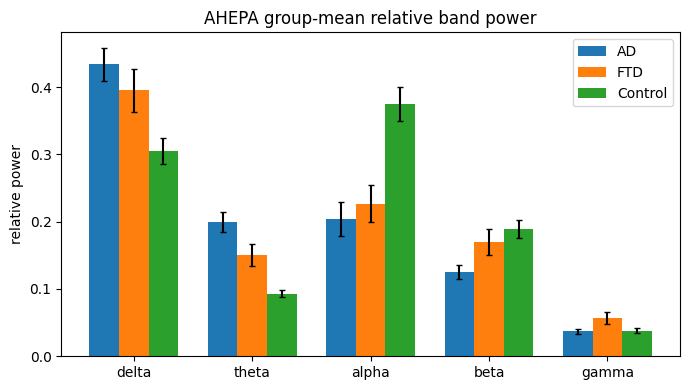

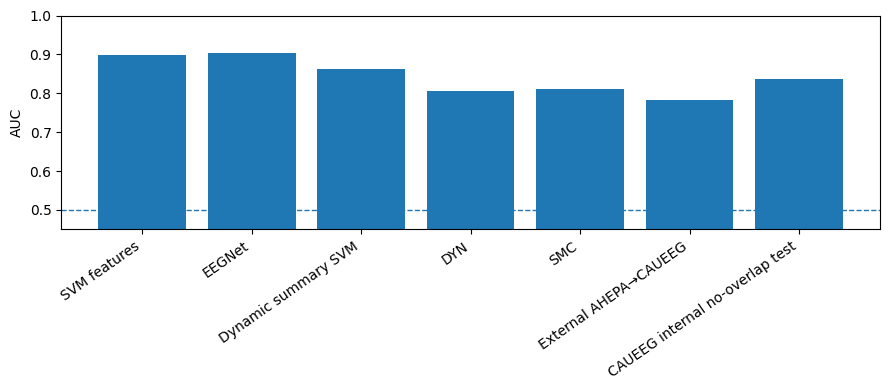

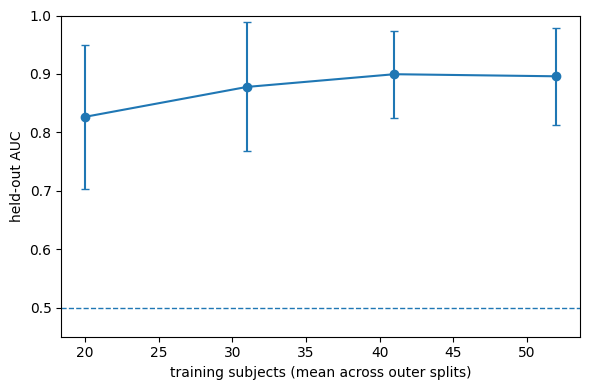


LOCKED RUN COMPLETE
Manifest: /content/drive/MyDrive/eeg_dementia_locked_results_2026/LOCKED_RESULT_MANIFEST.json
Bundle: /content/drive/MyDrive/eeg_dementia_locked_results_2026/eeg_dementia_locked_results.zip
Total timed stages: 82.27217001517614 minutes


In [30]:
# CAUEEG demographics and split inventory
cdem=[]
for g,s in caueeg.groupby('group'):
    age=pd.to_numeric(s.Age,errors='coerce')
    r={'group':g,'n_recordings':len(s),'age_mean':age.mean(),'age_sd':age.std(),'age_missing':age.isna().sum(),
       'no_overlap_train':int((s.no_overlap_split=='train_split').sum()),'no_overlap_validation':int((s.no_overlap_split=='validation_split').sum()),'no_overlap_test':int((s.no_overlap_split=='test_split').sum())}
    if 'patient_id' in s: r['unique_patient_ids']=s.patient_id.nunique(dropna=True)
    else: r['unique_patient_ids']='not_available_in_annotation'
    if 'Sex' in s: r['sex_counts']=json.dumps(s.Sex.fillna('missing').astype(str).value_counts().to_dict())
    else: r['sex_counts']='not_available_in_annotation'
    cdem.append(r)
caueeg_demog=pd.DataFrame(cdem); caueeg_demog.to_csv(RESULTS/'caueeg_demographics_and_splits.csv',index=False); display(caueeg_demog)

# Core figures regenerated from locked outputs.
# 1 band-power group means
fig,ax=plt.subplots(figsize=(7,4))
bns=list(BANDS); x=np.arange(len(bns)); groups=['A','F','C']; labels={'A':'AD','F':'FTD','C':'Control'}; width=.25
for j,g in enumerate(groups):
    if g not in set(ahepa.group): continue
    vals=[]; sem=[]
    for bn in bns:
        cols=[c for c in FEATCOLS if c.startswith(f'relpow_{bn}_')]; v=ahepa.loc[ahepa.group==g,cols].mean(axis=1); vals.append(v.mean()); sem.append(v.sem())
    ax.bar(x+(j-1)*width,vals,width,yerr=sem,label=labels[g],capsize=2)
ax.set_xticks(x); ax.set_xticklabels(bns); ax.set_ylabel('relative power'); ax.legend(); ax.set_title('AHEPA group-mean relative band power'); fig.tight_layout(); fig.savefig(RESULTS/'fig_bandpower_locked.png',dpi=200); plt.show()

# 2 model AUC summary
plot_rows=[('SVM features',primary['pooled_oof_auc']),('EEGNet',eeg_auc),('Dynamic summary SVM',dyn_svm['pooled_oof_auc'])]
for _,r in gsumm.iterrows():
    if r['model'] in ['dyn','smc']: plot_rows.append((r['model'].upper(),r['auc']))
plot_rows += [('External AHEPA→CAUEEG',ext_auc),('CAUEEG internal no-overlap test',internal['test_auc'])]
pr=pd.DataFrame(plot_rows,columns=['model','auc'])
fig,ax=plt.subplots(figsize=(9,4)); ax.bar(np.arange(len(pr)),pr.auc); ax.axhline(.5,ls='--',lw=1); ax.set_ylim(.45,1); ax.set_xticks(np.arange(len(pr))); ax.set_xticklabels(pr.model,rotation=35,ha='right'); ax.set_ylabel('AUC'); fig.tight_layout(); fig.savefig(RESULTS/'fig_model_auc_locked.png',dpi=200); plt.show()

# 3 learning curve
lcplot=lcdf.groupby('fraction_of_outer_train').agg(n_train=('n_train','mean'),mean_auc=('auc','mean'),sd_auc=('auc','std')).reset_index()
fig,ax=plt.subplots(figsize=(6,4)); ax.errorbar(lcplot.n_train,lcplot.mean_auc,yerr=lcplot.sd_auc,marker='o',capsize=3); ax.axhline(.5,ls='--',lw=1); ax.set_xlabel('training subjects (mean across outer splits)'); ax.set_ylabel('held-out AUC'); ax.set_ylim(.45,1); fig.tight_layout(); fig.savefig(RESULTS/'fig_learning_curve_locked.png',dpi=200); plt.show()

# Software/environment record
import importlib.metadata as im
packages=['numpy','scipy','pandas','scikit-learn','mne','torch','networkx','matplotlib','statsmodels','neuroCombat']
def safe_version(p):
    if p=='torch': return torch.__version__
    try: return im.version(p)
    except im.PackageNotFoundError: return 'not-installed'
versions={p:safe_version(p) for p in packages}
env={'python':platform.python_version(),'platform':platform.platform(),'device':DEVICE,'gpu':torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'cpu','packages':versions,
     'analysis_seed':SEED,'deep_seeds':CFG['DEEP_SEEDS'],'config':CFG}
json.dump(env,open(RESULTS/'environment.json','w'),indent=2)

# Consolidated source-of-truth manifest
manifest={
 'ahepa_n_total':int(len(ahepa)),'ahepa_AD':int((ahepa.group=='A').sum()),'ahepa_FTD':int((ahepa.group=='F').sum()),'ahepa_control':int((ahepa.group=='C').sum()),
 'primary_svm':primary,'primary_permutation':perm,
 'eegnet':json.load(open(RESULTS/'eegnet_summary.json')),
 'dynamic_models':gsumm.to_dict(orient='records'),
 'external_primary':ext_summary,
 'caueeg_no_overlap_internal':internal,
 'site_threshold_test':threshold_test,
 'probability_calibration':cal_summary,
 'combat_secondary':combat_summary,
 'same_site_FTD_transfer':cross_endpoint,
 'caueeg_retained_recordings':int(len(caueeg)),
 'caueeg_retained_by_group':{str(k):int(v) for k,v in caueeg.group.value_counts().items()},
 'timings_minutes':{k:v/60 for k,v in TIMINGS.items()},
}
# convert any numpy values recursively for JSON
def pyify(x):
    if isinstance(x,dict): return {str(k):pyify(v) for k,v in x.items()}
    if isinstance(x,(list,tuple)): return [pyify(v) for v in x]
    if isinstance(x,np.ndarray): return x.tolist()
    if isinstance(x,(np.floating,np.integer)): return x.item()
    return x
json.dump(pyify(manifest),open(RESULTS/'LOCKED_RESULT_MANIFEST.json','w'),indent=2)

# Zip all report-facing outputs for easy upload back into ChatGPT.
archive=shutil.make_archive('/content/eeg_dementia_locked_results','zip',RESULTS)
shutil.copy2(archive,RESULTS/'eeg_dementia_locked_results.zip')
print('\nLOCKED RUN COMPLETE')
print('Manifest:',RESULTS/'LOCKED_RESULT_MANIFEST.json')
print('Bundle:',RESULTS/'eeg_dementia_locked_results.zip')
print('Total timed stages:',sum(TIMINGS.values())/60,'minutes')


# After the run

For the report update, upload **`eeg_dementia_locked_results.zip`** (or at minimum `LOCKED_RESULT_MANIFEST.json`, the demographic/QC CSVs, and the generated figures). The dissertation should then be rewritten against these locked outputs, including corrected Methods, Results, Discussion, Limitations, Abstract, tables, figures and reference mapping.